# 🍕 Food Calorie Prediction System

## AI Based Food Image Classification and Calorie Estimation

This project develops an AI based food recognition system capable of:

1. Accepting a food image as input
2. Identifying the food category using deep learning
3. Reporting the prediction confidence
4. Displaying the top predicted food categories
5. Estimating calories using a nutrition lookup database

## Machine Learning Approach

The project uses transfer learning with a pretrained EfficientNetV2B0 convolutional neural network.

The model is trained in two stages:

### Stage 1 - Transfer Learning
The pretrained ImageNet feature extractor is frozen and a new 101-class food classifier is trained.

### Stage 2 - Fine Tuning
The later layers of the pretrained network are gradually unfrozen and trained with a very small learning rate so that the visual features can adapt specifically to food images.

## Dataset

The Food 101 dataset is used.

It contains:

- 101 food categories
- 101,000 images
- 750 training images per category
- 250 validation images per category

## Important Note

The calorie values produced by this project are approximate reference values.

Image classification identifies the food category, but an image alone cannot reliably determine the exact portion size. Therefore, calorie estimation is treated as an approximate nutritional lookup rather than an exact measurement.

## 1. Environment and Library Setup

The first stage prepares the Google Colab environment.

We intentionally do **not** upgrade protobuf or other core packages because unnecessary package upgrades can create dependency conflicts.

The implementation uses TensorFlow/Keras for deep learning and scikit-learn for evaluation.

In [ ]:
# STEP 1A: BASIC ENVIRONMENT CHECK

import sys
import os
import random
import numpy as np

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Python executable:
/usr/bin/python3


In [ ]:
# STEP 1A: BASIC ENVIRONMENT CHECK
import sys
import os
import random
import numpy as np

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

Python executable:
/usr/bin/python3


In [ ]:
# STEP 1B: CHECK TENSORFLOW

import tensorflow as tf

print("TensorFlow version:")
print(tf.__version__)

# Check whether Google Colab has provided a GPU.
gpus = tf.config.list_physical_devices("GPU")

print("\nNumber of GPUs detected:", len(gpus))

if gpus:

    print("\nGPU detected:")

    for gpu in gpus:
        print("   ", gpu)

else:

    print("\nWARNING: No GPU detected.")
    print(
        "Training Food-101 on CPU will be significantly slower."
    )

/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

TensorFlow version:
2.20.0

Number of GPUs detected: 1

GPU detected:
    PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# STEP 1C: INSTALL A COMPATIBLE TENSORFLOW DATASETS VERSION

import subprocess
import sys

print("Installing TensorFlow Datasets...")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-cache-dir",
    "tensorflow-datasets==4.9.9"
])

print("\nTensorFlow Datasets installation completed.")

Installing TensorFlow Datasets...

TensorFlow Datasets installation completed.


# 2. TensorFlow Datasets Verification

Before loading the complete Food-101 dataset, we first verify that
TensorFlow Datasets is installed correctly.

This step is important because the previous notebook produced:

AttributeError: module 'tensorflow_datasets' has no attribute 'load'

The current environment has been repaired, so we verify the standard
TFDS APIs before proceeding.

We will check:

- TensorFlow Datasets version
- tfds.load()
- tfds.builder()
- Food-101 availability
- Number of classes
- Number of training and validation images

In [ ]:
# STEP 2A: FIX PROTOBUF / TFDS COMPATIBILITY

import sys
import subprocess

print("Installing compatible protobuf runtime...")

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-cache-dir",
    "--force-reinstall",
    "protobuf==6.31.1"
])

print("\nProtobuf installation completed.")

Installing compatible protobuf runtime...

Protobuf installation completed.


## 2.1 Verify TensorFlow, Protobuf and TensorFlow Datasets

After correcting the dependency mismatch, the environment is checked again before
Food-101 is loaded.

This prevents us from starting a long dataset download or model training process
when the underlying libraries are not compatible.

In [ ]:
# STEP 2B: VERIFY ENVIRONMENT AFTER PROTOBUF FIX

import tensorflow as tf
import tensorflow_datasets as tfds

from importlib.metadata import version


# Check TensorFlow

print("TensorFlow version:")
print(tf.__version__)


# Check protobuf

print("\nProtobuf version:")

try:

    print(
        version("protobuf")
    )

except Exception as e:

    print(
        "Could not determine protobuf version."
    )

    print(e)


# Check TensorFlow Datasets

print("\nTensorFlow Datasets version:")

try:

    print(
        version("tensorflow-datasets")
    )

except Exception as e:

    print(
        "Could not determine TFDS version."
    )

    print(e)


# Verify TFDS API

print("\nTFDS API:")

print(
    "tfds.load    :",
    hasattr(tfds, "load")
)

print(
    "tfds.builder :",
    hasattr(tfds, "builder")
)


# Show package location

print("\nTFDS location:")

print(
    tfds.__file__
)

TensorFlow version:
2.20.0

Protobuf version:
6.31.1

TensorFlow Datasets version:
4.9.9

TFDS API:
tfds.load    : True
tfds.builder : True

TFDS location:
/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py


## 2.2 Verify Food-101 Metadata

Before downloading and preparing the complete dataset, the Food-101 dataset
builder is checked.

This confirms that TensorFlow Datasets can recognize the dataset and its
metadata before the computationally heavier loading process begins.

In [ ]:
# STEP 2C: CHECK FOOD-101 DATASET BUILDER

print("Checking Food-101 dataset builder...")

# Create the Food-101 builder.
food101_builder = tfds.builder(
    "food101"
)

print("\nFood-101 builder created successfully.")

print(
    "Dataset name:",
    food101_builder.name
)

print(
    "Dataset version:",
    food101_builder.info.version
)

print(
    "Number of classes:",
    food101_builder.info.features[
        "label"
    ].num_classes
)

print("\nFood-101 builder is available.")
print(
    "The dataset now needs to be prepared before loading."
)

Checking Food-101 dataset builder...

Food-101 builder created successfully.
Dataset name: food101
Dataset version: 2.0.0
Number of classes: 101

Food-101 builder is available.
The dataset now needs to be prepared before loading.


## 2.3 Prepare the Food-101 Dataset


This is the expensive dataset step. Once the final classification model is
trained and saved, this preparation step will NOT be required for ordinary
food image prediction.

In [ ]:
# STEP 2D: PREPARE FOOD-101 DATASET

print("=" * 60)
print("PREPARING FOOD-101 DATASET")
print("=" * 60)

print(
    "\nFood-101 has not yet been prepared in this Colab runtime."
)

print(
    "TensorFlow Datasets will download and prepare the dataset."
)

print(
    "\nThis may take several minutes."
)

print(
    "Please allow this cell to finish completely."
)

print("=" * 60)


# Download and prepare Food-101.

# download_and_prepare() creates the local TFDS dataset files
# and metadata needed by tfds.load().

food101_builder.download_and_prepare()


print("\n")
print("=" * 60)
print("FOOD-101 PREPARATION COMPLETE")
print("=" * 60)

PREPARING FOOD-101 DATASET

Food-101 has not yet been prepared in this Colab runtime.
TensorFlow Datasets will download and prepare the dataset.

This may take several minutes.
Please allow this cell to finish completely.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.TITUNV_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.TITUNV_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


FOOD-101 PREPARATION COMPLETE


In [ ]:
# STEP 2E: VERIFY FOOD-101 PREPARATION

print("Verifying prepared Food-101 dataset...")

food101_builder = tfds.builder(
    "food101"
)


print("\nDataset name:")
print(
    food101_builder.name
)


print("\nDataset version:")
print(
    food101_builder.info.version
)


print("\nNumber of classes:")
print(
    food101_builder.info.features[
        "label"
    ].num_classes
)


print("\nTraining examples:")
print(
    food101_builder.info.splits[
        "train"
    ].num_examples
)


print("\nValidation examples:")
print(
    food101_builder.info.splits[
        "validation"
    ].num_examples
)

Verifying prepared Food-101 dataset...

Dataset name:
food101

Dataset version:
2.0.0

Number of classes:
101

Training examples:
75750

Validation examples:
25250


# 3. Load and Prepare the Food-101 Dataset

The Food-101 dataset has now been successfully prepared.

In this section, the prepared dataset is loaded into TensorFlow.

We will then:

- Extract the 101 food class names
- Inspect sample images
- Resize images to the input size required by EfficientNetV2B0
- Create optimized training and validation pipelines

The images are not permanently resized or modified on disk. The resizing
operation is performed as part of the TensorFlow input pipeline.

This allows the original dataset to remain unchanged.

In [ ]:
# STEP 3A: LOAD THE PREPARED FOOD-101 DATASET

print("Loading prepared Food-101 dataset...")

# Load the training and validation splits.
#
# Because Food-101 has already been prepared, this should NOT
# download the dataset again.
#
# If the dataset is already available in the current TFDS
# directory, TensorFlow Datasets will reuse it.

(train_raw, validation_raw), dataset_info = tfds.load(

    "food101",

    split=[
        "train",
        "validation"
    ],

    as_supervised=True,

    with_info=True,

    shuffle_files=True
)


print("\nFood-101 loaded successfully.")

Loading prepared Food-101 dataset...

Food-101 loaded successfully.


In [ ]:
# STEP 3B: DATASET INFORMATION

# Extract important dataset information.

NUM_TRAIN = (
    dataset_info
    .splits["train"]
    .num_examples
)

NUM_VALIDATION = (
    dataset_info
    .splits["validation"]
    .num_examples
)

NUM_CLASSES = (
    dataset_info
    .features["label"]
    .num_classes
)


# Extract the food class names.

class_names = (
    dataset_info
    .features["label"]
    .names
)


# Display information.

print("=" * 60)
print("FOOD-101 DATASET INFORMATION")
print("=" * 60)

print(
    f"Training images   : {NUM_TRAIN:,}"
)

print(
    f"Validation images : {NUM_VALIDATION:,}"
)

print(
    f"Number of classes : {NUM_CLASSES}"
)

print("=" * 60)



# Safety checks

if NUM_CLASSES != 101:

    raise ValueError(
        "Expected 101 Food-101 classes."
    )


if len(class_names) != 101:

    raise ValueError(
        "Expected 101 class names."
    )


print(
    "\nDataset information verified successfully."
)

FOOD-101 DATASET INFORMATION
Training images   : 75,750
Validation images : 25,250
Number of classes : 101

Dataset information verified successfully.


## 3.1 Food-101 Class Names

Each Food-101 image is associated with an integer label.

For example, the label might be:

0

or

50

The class name list allows us to convert that integer back into a human readable
food name such as:

pizza

or

baklava

The same class name ordering will later be saved together with the trained model
so that predictions are interpreted correctly.

In [ ]:
# STEP 3C: DISPLAY ALL FOOD-101 CLASS NAMES

print("Food-101 Classes")
print("=" * 60)

for index, food_name in enumerate(class_names):

    print(
        f"{index:3d} -> {food_name}"
    )

Food-101 Classes
  0 -> apple_pie
  1 -> baby_back_ribs
  2 -> baklava
  3 -> beef_carpaccio
  4 -> beef_tartare
  5 -> beet_salad
  6 -> beignets
  7 -> bibimbap
  8 -> bread_pudding
  9 -> breakfast_burrito
 10 -> bruschetta
 11 -> caesar_salad
 12 -> cannoli
 13 -> caprese_salad
 14 -> carrot_cake
 15 -> ceviche
 16 -> cheesecake
 17 -> cheese_plate
 18 -> chicken_curry
 19 -> chicken_quesadilla
 20 -> chicken_wings
 21 -> chocolate_cake
 22 -> chocolate_mousse
 23 -> churros
 24 -> clam_chowder
 25 -> club_sandwich
 26 -> crab_cakes
 27 -> creme_brulee
 28 -> croque_madame
 29 -> cup_cakes
 30 -> deviled_eggs
 31 -> donuts
 32 -> dumplings
 33 -> edamame
 34 -> eggs_benedict
 35 -> escargots
 36 -> falafel
 37 -> filet_mignon
 38 -> fish_and_chips
 39 -> foie_gras
 40 -> french_fries
 41 -> french_onion_soup
 42 -> french_toast
 43 -> fried_calamari
 44 -> fried_rice
 45 -> frozen_yogurt
 46 -> garlic_bread
 47 -> gnocchi
 48 -> greek_salad
 49 -> grilled_cheese_sandwich
 50 -> gri

## 3.2 Visual Inspection of the Dataset

Before preprocessing the complete dataset, several training images are displayed.

This is an important quality check.

It allows us to verify that:

- Images are loading correctly
- Labels correspond to the images
- The images contain actual food examples
- Different food categories have different visual characteristics

Food photographs can contain different backgrounds, orientations, lighting
conditions and presentation styles. These variations are one reason why
data augmentation will be introduced later.

In [ ]:
import matplotlib.pyplot as plt

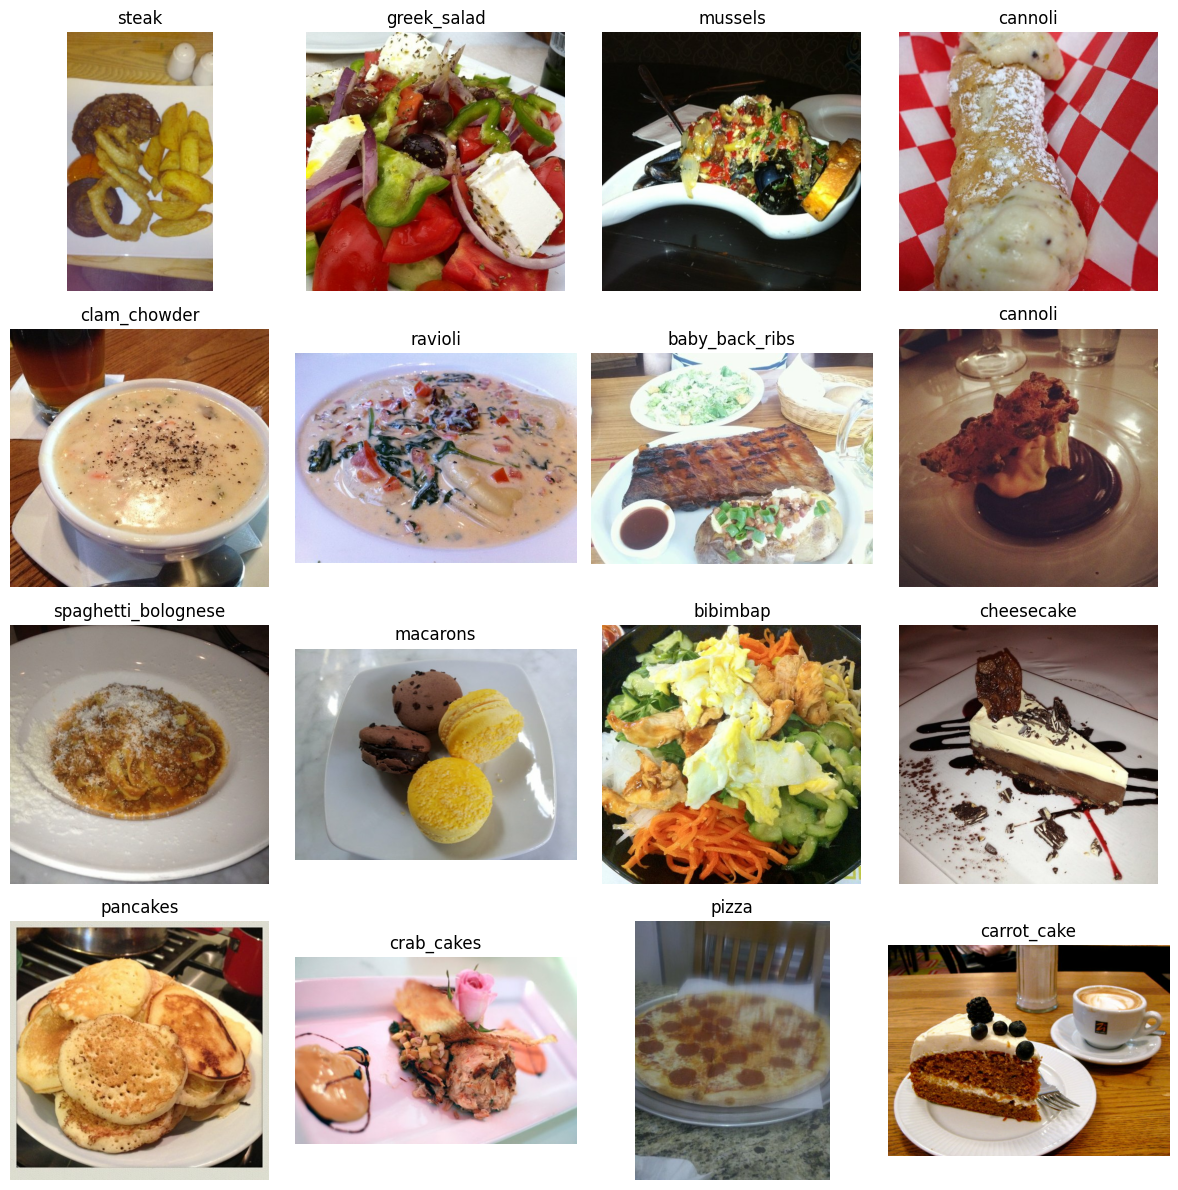

In [ ]:
# STEP 3D: VISUALIZE SAMPLE FOOD-101 IMAGES

plt.figure(
    figsize=(12, 12)
)

# Take 16 images from the training dataset.
for i, (image, label) in enumerate(
    train_raw.take(16)
):

    plt.subplot(
        4,
        4,
        i + 1
    )

    # Convert the TensorFlow image to a displayable image.
    plt.imshow(
        image.numpy()
    )

    # Convert the integer TensorFlow label to a Python integer.
    label_index = int(
        label.numpy()
    )

    plt.title(
        class_names[label_index]
    )

    plt.axis("off")


plt.tight_layout()

plt.show()

## 3.3 Image Size and Model Input

The original Food-101 images do not all have the same dimensions.

Neural networks require a consistent input shape.

For this project, images will be resized to:

224 × 224 × 3

where:

- 224 = image height
- 224 = image width
- 3 = RGB color channels

This input size is appropriate for the EfficientNetV2B0 architecture that will
be used later.

The resizing is performed dynamically as part of the TensorFlow data pipeline.

In [ ]:
# STEP 3E: MEMORY-EFFICIENT DATA CONFIGURATION

# Image dimensions expected by EfficientNetV2B0.

IMAGE_SIZE = 224


# Reduce batch size from 32 to 16.
#
# A smaller batch requires less RAM during preprocessing and
# less memory for intermediate tensors during training.
#
# This does NOT change the model architecture or the number
# of training images.

BATCH_SIZE = 16


# Use a controlled number of parallel preprocessing operations.
#
# AUTOTUNE can sometimes create more parallel work than is
# desirable on a RAM-limited Colab session.

NUM_PARALLEL_CALLS = 4


# Limit prefetching to one batch.
#
# This prevents TensorFlow from keeping many future batches
# in memory simultaneously.

PREFETCH_BUFFER = 1


print(
    "Image size:",
    IMAGE_SIZE,
    "x",
    IMAGE_SIZE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Parallel preprocessing calls:",
    NUM_PARALLEL_CALLS
)

print(
    "Prefetch buffer:",
    PREFETCH_BUFFER
)

Image size: 224 x 224
Batch size: 16
Parallel preprocessing calls: 4
Prefetch buffer: 1


## 3.4 Image Resizing Function

The following function resizes each image to 224 × 224 pixels.

The image is converted to float32.

We intentionally do not apply MobileNetV2's preprocess_input() function.

The model used later is EfficientNetV2B0, which includes its own preprocessing
when include_preprocessing=True.

Therefore, the input pipeline keeps pixel values in the normal image range and
lets EfficientNetV2 handle its model  specific preprocessing.

In [ ]:

# STEP 3F: MEMORY-EFFICIENT IMAGE RESIZING

def resize_image(
    image,
    label
):

    # Convert image pixels to float32.
    #
    # This is required because the neural network will work
    # with floating-point image values.

    image = tf.cast(
        image,
        tf.float32
    )


    # Resize every image to 224 x 224 pixels.
    #
    # EfficientNetV2B0 will receive images with this fixed
    # spatial size.


    image = tf.image.resize(
        image,
        [
            IMAGE_SIZE,
            IMAGE_SIZE
        ],
        method="bilinear"
    )


    return image, label


# Create the training preprocessing pipeline.
#
# IMPORTANT:
# We use NUM_PARALLEL_CALLS instead of AUTOTUNE.
#
# This is intentional because the previous training attempt
# exhausted the Colab system RAM.

train_resized = train_raw.map(
    resize_image,
    num_parallel_calls=NUM_PARALLEL_CALLS
)


# Create the validation preprocessing pipeline.

validation_resized = validation_raw.map(
    resize_image,
    num_parallel_calls=NUM_PARALLEL_CALLS
)


print(
    "Memory-efficient resizing pipelines created successfully."
)

Memory-efficient resizing pipelines created successfully.


In [ ]:
# STEP 3G: APPLY MEMORY-EFFICIENT RESIZING

print("Creating resized dataset pipelines...")

# Apply the resize_image() function to the training dataset.
#
# We explicitly limit parallel processing to NUM_PARALLEL_CALLS
# instead of using AUTOTUNE.
#
# This helps control RAM usage in Google Colab.

train_resized = train_raw.map(
    resize_image,
    num_parallel_calls=NUM_PARALLEL_CALLS
)


# Apply the same preprocessing to the validation dataset.

validation_resized = validation_raw.map(
    resize_image,
    num_parallel_calls=NUM_PARALLEL_CALLS
)


print(
    "Training resizing pipeline created."
)

print(
    "Validation resizing pipeline created."
)

print(
    "\nImages will be resized to:",
    f"{IMAGE_SIZE} x {IMAGE_SIZE}"
)

print(
    "Parallel preprocessing calls:",
    NUM_PARALLEL_CALLS
)

Creating resized dataset pipelines...
Training resizing pipeline created.
Validation resizing pipeline created.

Images will be resized to: 224 x 224
Parallel preprocessing calls: 4


## 3.5 Optimizing the TensorFlow Data Pipeline

Food-101 contains tens of thousands of images, so efficient data loading is
important.

The pipeline uses:

### Shuffle
Training images are randomly shuffled between training iterations.

### Batch
Multiple images are processed together by the GPU.

### Prefetch
TensorFlow prepares future batches while the current batch is being processed.

We deliberately do NOT cache the complete resized dataset in RAM.

Food-101 is large, and caching all resized floating point images could consume
a very large amount of memory.

Instead, we use parallel mapping, batching and prefetching, which gives a good
balance between speed and memory usage in Google Colab.

In [ ]:
# STEP 3H: MEMORY-EFFICIENT TF.DATA PIPELINE

print(
    "Building memory-efficient training pipeline..."
)


# Shuffle only a portion of the dataset.
#
# We do NOT shuffle all 75,750 images in memory.
#
# A buffer of 2,000 still provides substantial randomization
# while significantly reducing memory requirements.

train_resized = train_resized.shuffle(

    buffer_size=2000,

    seed=42,

    reshuffle_each_iteration=True
)


# Batch the images.

train_ds = train_resized.batch(

    BATCH_SIZE,

    drop_remainder=False
)

validation_ds = validation_resized.batch(

    BATCH_SIZE,

    drop_remainder=False
)


# Prefetch ONLY one batch.
#
# We deliberately avoid AUTOTUNE here because our Colab
# session has already demonstrated that system RAM is limited.

train_ds = train_ds.prefetch(
    PREFETCH_BUFFER
)

validation_ds = validation_ds.prefetch(
    PREFETCH_BUFFER
)


print(
    "Training pipeline created successfully."
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Shuffle buffer:",
    2000
)

print(
    "Prefetch buffer:",
    PREFETCH_BUFFER
)

Building memory-efficient training pipeline...
Training pipeline created successfully.
Batch size: 16
Shuffle buffer: 2000
Prefetch buffer: 1


In [ ]:
# STEP 3I: VERIFY PREPROCESSED BATCH

sample_batch_images, sample_batch_labels = next(
    iter(train_ds)
)


print(
    "Batch image shape:",
    sample_batch_images.shape
)

print(
    "Batch label shape:",
    sample_batch_labels.shape
)

print(
    "Image data type:",
    sample_batch_images.dtype
)

print(
    "Minimum pixel value:",
    float(
        tf.reduce_min(
            sample_batch_images
        )
    )
)

print(
    "Maximum pixel value:",
    float(
        tf.reduce_max(
            sample_batch_images
        )
    )
)

Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)
Image data type: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 255.0


## 3.6 Verify the Resized Images

A final visual check is performed after resizing.

This confirms that the preprocessing operation has not corrupted the food
images before the images are passed into the neural network.

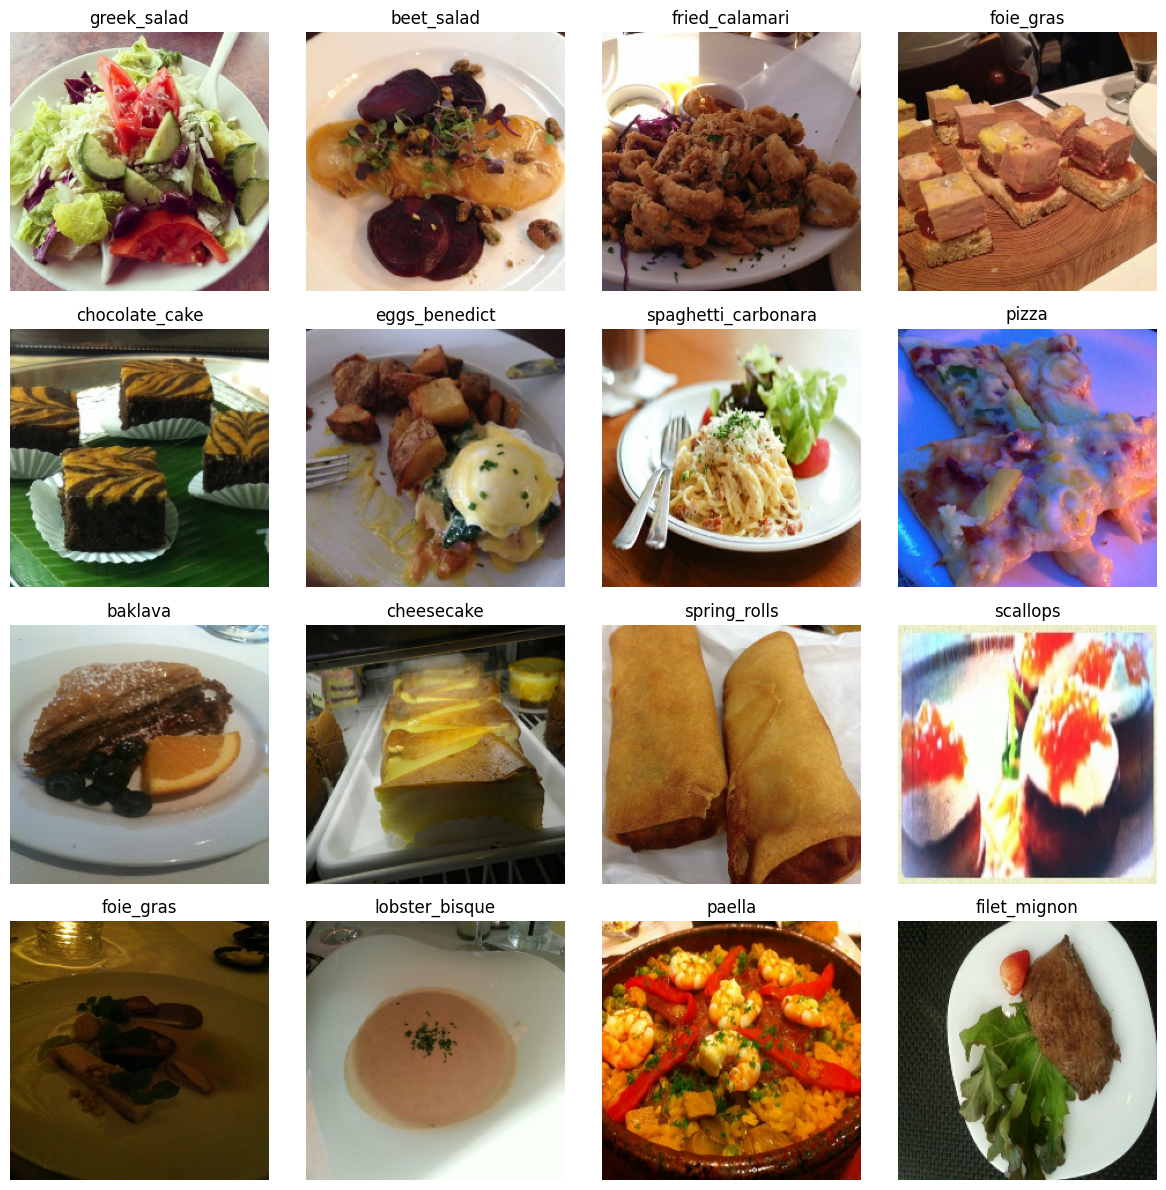

In [ ]:
# STEP 3J: VISUALIZE PREPROCESSED IMAGES

# Import NumPy here as well so this visualization cell can
# run independently after a Colab runtime restart.
import numpy as np

plt.figure(
    figsize=(12, 12)
)

for i in range(16):

    plt.subplot(
        4,
        4,
        i + 1
    )

    # Display the resized image.
    #
    # The images are currently float32, so we convert them
    # back to uint8 only for visualization.
    plt.imshow(
        sample_batch_images[i].numpy().astype(
            np.uint8
        )
    )

    # Get the integer label for this image.
    label_index = int(
        sample_batch_labels[i].numpy()
    )

    # Convert the integer label into the food name.
    plt.title(
        class_names[label_index]
    )

    plt.axis("off")


plt.tight_layout()

plt.show()

# 4. Build the Food Classification Model

## Transfer Learning with EfficientNetV2B0

A convolutional neural network is required to learn visual features from the
food images.

Instead of training a CNN completely from random initialization, this project
uses transfer learning.

EfficientNetV2B0 is loaded with weights pretrained on ImageNet.

The pretrained network has already learned useful visual features such as:

- Edges
- Textures
- Shapes
- Patterns
- Object structures

The original ImageNet classification layer is removed and replaced with a new
classifier containing 101 output neurons, one for each Food-101 category.

### Model structure

Input Image
->
Data Augmentation
->
EfficientNetV2B0
->
Global Average Pooling
->
Dropout
->
Dense Layer
->
101 Food Classes

During the first training stage, the pretrained EfficientNetV2B0 layers are
frozen. Only the newly added Food-101 classifier is trained.

After this stage, selected later layers of EfficientNetV2B0 will be fine tuned
using a much smaller learning rate.

In [ ]:
# STEP 4A: IMPORT MODEL COMPONENTS

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import EfficientNetV2B0

print("Model components imported successfully.")

Model components imported successfully.


## 4.1 Data Augmentation

Food photographs can vary considerably even when they belong to the same food
category.

For example, a pizza may be photographed:

- From different angles
- At different distances
- Under different lighting
- In different positions
- With different backgrounds

Data augmentation creates small variations of training images so that the model
does not become overly dependent on one particular visual arrangement.

The transformations used here are intentionally moderate.

We do not want to transform the food so aggressively that the image no longer
resembles the original food.

In [ ]:
# STEP 4B: CREATE DATA AUGMENTATION

data_augmentation = keras.Sequential(

    [

        # Horizontal flipping
        #
        # Food generally remains the same food when viewed
        # from the opposite horizontal direction.

        layers.RandomFlip(
            mode="horizontal"
        ),


        # Small rotation
        #
        # Simulates slightly different camera orientations.

        layers.RandomRotation(
            factor=0.08
        ),


        # Small zoom variation
        #
        # Helps when the food occupies different amounts of
        # the image.

        layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            width_factor=(-0.10, 0.10)
        ),


        # Small translation
        #
        # Makes the model less dependent on the food being
        # perfectly centered.

        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08
        ),


        # Slight contrast variation
        #
        # Helps with different lighting conditions.

        layers.RandomContrast(
            factor=0.10
        )

    ],

    name="food_image_augmentation"
)


print(
    "Data augmentation pipeline created successfully."
)

Data augmentation pipeline created successfully.


## 4.2 Load the Pretrained EfficientNetV2B0 Backbone

EfficientNetV2B0 is used as the feature extraction component.

The ImageNet classification head is removed because the original model predicts
ImageNet categories, while our project requires exactly 101 Food-101 categories.

The pretrained weights are retained.

Initially, the backbone is frozen.

This means that during the first training stage, the pretrained visual features
are not changed.

Only our new Food-101 classification layers will learn.

In [ ]:
# STEP 4C: LOAD PRETRAINED EFFICIENTNETV2B0

base_model = EfficientNetV2B0(

    # Use ImageNet pretrained weights.
    weights="imagenet",

    # Remove the original ImageNet classification layer.
    include_top=False,

    # Our images are 224 x 224 RGB images.
    input_shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ),

    # EfficientNetV2 handles its own input preprocessing.
    include_preprocessing=True
)


# IMPORTANT:
#
# Freeze the pretrained backbone for Stage 1.

base_model.trainable = False


print(
    "EfficientNetV2B0 loaded successfully."
)

print(
    "Pretrained backbone trainable:",
    base_model.trainable
)

EfficientNetV2B0 loaded successfully.
Pretrained backbone trainable: False


## 4.3 Build the Complete Classification Model

The pretrained EfficientNetV2B0 produces convolutional feature maps.

Global Average Pooling converts these feature maps into a compact feature
representation.

A Dropout layer is then used as regularization.

Finally, a Dense layer with 101 outputs produces the probability distribution
over the Food-101 categories.

The final layer uses softmax because this is a single label classification
problem: each image belongs to one primary Food-101 category.

In [ ]:
# STEP 4D: BUILD COMPLETE FOOD CLASSIFICATION MODEL

# Input layer

inputs = keras.Input(

    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    ),

    name="food_image"
)


# Data augmentation

x = data_augmentation(
    inputs
)


# EfficientNetV2B0 feature extractor
#
# training=False is intentional during the frozen transfer
# learning stage.
#
# It keeps the pretrained BatchNormalization layers operating
# in inference mode.

x = base_model(

    x,

    training=False
)


# Global Average Pooling
#
# Reduces the spatial feature maps to one feature vector.

x = layers.GlobalAveragePooling2D(

    name="global_average_pooling"

)(x)


# Dropout regularization

x = layers.Dropout(

    0.30,

    name="classifier_dropout"

)(x)


# Final Food-101 classifier
#
# There are exactly 101 output neurons.
#
# float32 is explicitly used for the final layer so that the
# softmax probabilities remain numerically stable if mixed
# precision is enabled.

outputs = layers.Dense(

    NUM_CLASSES,

    activation="softmax",

    dtype="float32",

    name="food_classifier"

)(x)


# Create final Keras model

model = keras.Model(

    inputs=inputs,

    outputs=outputs,

    name="Food101_EfficientNetV2B0"

)


print(
    "\nFood classification model created successfully."
)


Food classification model created successfully.


In [ ]:
# STEP 4E: DISPLAY MODEL SUMMARY

model.summary()

Model: "Food101_EfficientNetV2B0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ food_image (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_image_augmentation         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_classifier (Dense)         │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,048,693 (23.07 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:

# STEP 4F: VERIFY TRAINABLE PARAMETERS

trainable_parameters = np.sum(
    [
        np.prod(variable.shape)
        for variable in model.trainable_variables
    ]
)

non_trainable_parameters = np.sum(
    [
        np.prod(variable.shape)
        for variable in model.non_trainable_variables
    ]
)


print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Non-trainable parameters:",
    f"{non_trainable_parameters:,}"
)


print(
    "\nEfficientNetV2B0 trainable:",
    base_model.trainable
)

Trainable parameters: 129,381
Non-trainable parameters: 5,919,354

EfficientNetV2B0 trainable: False


## 4.4 Why the Model is Trained in Two Stages

The model will not immediately fine tune all EfficientNetV2B0 layers.

Instead, two stages are used.

### Stage 1 : Transfer Learning

EfficientNetV2B0:

**Frozen**

Food-101 classifier:

**Trainable**

The new classifier learns how to interpret the pretrained visual features.

### Stage 2 :: Fine Tuning

Later, selected layers of EfficientNetV2B0 will become trainable.

A much smaller learning rate will be used.

This allows the pretrained features to adapt to food specific visual patterns
without destroying the useful ImageNet representations.

This staged approach is used because directly iss changing all pretrained weights
from the beginning can cause the pretrained representations to be altered too
aggressively.

# 5. Compile the Transfer Learning Model

The EfficientNetV2B0 architecture has now been created.

Before training, the model must be compiled with:

- An optimizer
- A loss function
- Evaluation metrics

Because Food-101 provides one integer label for each image, sparse categorical
crossentropy is appropriate.

The AdamW optimizer is used because it combines adaptive gradient updates with
weight decay regularization.

A relatively small learning rate is selected for the first transfer-learning
stage because the pretrained EfficientNetV2B0 backbone is frozen and only the
new classification head needs to learn.

In [ ]:
# STEP 5A: COMPILE MODEL FOR TRANSFER LEARNING

# Optimizer

optimizer = keras.optimizers.AdamW(

    learning_rate=1e-3,

    weight_decay=1e-4
)


# Compile model
#
# sparse_categorical_crossentropy is used because our labels
# are integer values from 0 to 100 rather than one-hot vectors.

model.compile(

    optimizer=optimizer,

    loss=keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),

        keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)


print("Model compiled successfully.")

Model compiled successfully.


## 5.1 Training Callbacks

Training a deep learning model can take a significant amount of time.

Callbacks allow the training process to automatically respond to the model's
validation performance.

### ModelCheckpoint

The best validation model is saved automatically.

This is important because the final epoch is not necessarily the best model.

### EarlyStopping

Training stops if validation performance stops improving.

This helps prevent unnecessary training and reduces overfitting.

### ReduceLROnPlateau

If validation loss stops improving, the learning rate is reduced.

This allows the optimizer to make smaller updates when the model reaches a
plateau.

The best model is always restored after early stopping.

In [ ]:
import os

In [ ]:
# STEP 5B: CREATE TRAINING CALLBACKS

# Directory used for model checkpoints.
#
# This is stored in the Colab working directory for now.
# We will save the final model to Google Drive after training.

CHECKPOINT_DIR = "/content/food101_checkpoints"

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)


# Save the model whenever validation loss improves.

checkpoint_callback = keras.callbacks.ModelCheckpoint(

    filepath=os.path.join(
        CHECKPOINT_DIR,
        "food101_stage1_best.keras"
    ),

    monitor="val_loss",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)


# Stop training when validation loss has stopped improving.
#
# We allow several epochs without improvement because the model
# may temporarily plateau while the classifier is learning.

early_stopping_callback = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)


# Reduce learning rate when validation loss plateaus.

reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=1,

    min_lr=1e-6,

    verbose=1
)


# Store callbacks together for the training call.

callbacks_stage1 = [

    checkpoint_callback,

    early_stopping_callback,

    reduce_lr_callback
]


print(
    "Training callbacks created successfully."
)

Training callbacks created successfully.


## 5.2 Verify the Training Configuration

Before beginning training, the configuration is checked one final time.

At this stage:

- EfficientNetV2B0 is pretrained on ImageNet
- EfficientNetV2B0 is frozen
- The Food-101 classification head is trainable
- The output contains 101 classes
- The optimizer is AdamW
- Validation performance is monitored
- The best model will be automatically saved

This verification step is included to prevent accidentally training the wrong
architecture or accidentally fine tuning the backbone too early.

In [ ]:
# STEP 5C: FINAL TRAINING CONFIGURATION CHECK

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print(
    "Model:",
    model.name
)

print(
    "Number of classes:",
    NUM_CLASSES
)

print(
    "Image size:",
    f"{IMAGE_SIZE} x {IMAGE_SIZE}"
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Optimizer:",
    type(model.optimizer).__name__
)

print(
    "Learning rate:",
    float(
        keras.backend.get_value(
            model.optimizer.learning_rate
        )
    )
)

print(
    "Weight decay:",
    float(
        keras.backend.get_value(
            model.optimizer.weight_decay
        )
    )
)

print(
    "EfficientNetV2B0 trainable:",
    base_model.trainable
)

print(
    "Training dataset examples:",
    f"{NUM_TRAIN:,}"
)

print(
    "Validation dataset examples:",
    f"{NUM_VALIDATION:,}"
)

print("=" * 60)

TRAINING CONFIGURATION
Model: Food101_EfficientNetV2B0
Number of classes: 101
Image size: 224 x 224
Batch size: 16
Optimizer: AdamW
Learning rate: 0.0010000000474974513
Weight decay: 0.0001
EfficientNetV2B0 trainable: False
Training dataset examples: 75,750
Validation dataset examples: 25,250


# 6. Stage 1 — Transfer Learning Training

The first training stage trains the newly added Food-101 classification head.

The pretrained EfficientNetV2B0 feature extractor remains frozen.

This means that the model starts with visual features learned from ImageNet and
learns how to map those features to the 101 Food-101 categories.

A maximum of 8 epochs is used.

The model may stop earlier because EarlyStopping is enabled.

The best validation model is automatically saved to the checkpoint directory.

This stage is not the final model. After Stage 1, selected EfficientNetV2B0
layers will be fine-tuned using a much smaller learning rate.

In [ ]:
# STEP 6A: TRAIN STAGE 1

print("=" * 60)
print("STARTING STAGE 1 TRAINING")
print("=" * 60)

print("\nEfficientNetV2B0 backbone frozen:")
print(base_model.trainable)

print("\nMaximum epochs: 8")

print("\nTraining begins...\n")


# Train the model.
#
# Because base_model.trainable = False, only the newly added
# Food-101 classification layers are updated.
#
# The callbacks will:
#
# 1. Save the best validation model
# 2. Reduce learning rate when validation loss plateaus
# 3. Stop training when improvement stops
# 4. Restore the best weights


history_stage1 = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=8,

    callbacks=callbacks_stage1,

    verbose=1
)


print("\n")
print("=" * 60)
print("STAGE 1 TRAINING COMPLETE")
print("=" * 60)

STARTING STAGE 1 TRAINING

EfficientNetV2B0 backbone frozen:
False

Maximum epochs: 8

Training begins...

Epoch 1/8
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3745 - loss: 2.6693 - top_5_accuracy: 0.6336
Epoch 1: val_loss improved from None to 1.32147, saving model to /content/food101_checkpoints/food101_stage1_best.keras

Epoch 1: finished saving model to /content/food101_checkpoints/food101_stage1_best.keras
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 366s 72ms/step - accuracy: 0.4555 - loss: 2.2273 - top_5_accuracy: 0.7238 - val_accuracy: 0.6417 - val_loss: 1.3215 - val_top_5_accuracy: 0.8819 - learning_rate: 0.0010
Epoch 2/8
4734/4735 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5344 - loss: 1.8418 - top_5_accuracy: 0.7940
Epoch 2: val_loss improved from 1.32147 to 1.20727, saving model to /content/food101_checkpoints/food101_stage1_best.keras

Epoch 2: finished saving model to /content/food101_checkpoints/food101_stage1_best.keras
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 340s 71ms/ste

## 6.1 Inspect Stage 1 Training Results

The training history contains the metrics recorded during each epoch.

We examine the training and validation results to determine how well the
classifier learned the Food-101 categories.

Validation accuracy is particularly important because it measures performance
on images that were not used to update the model's weights.

The best validation result will be used when deciding how to proceed to the
fine tuning stage.

In [ ]:
import pandas as pd

In [ ]:
# STEP 6B: INSPECT STAGE 1 RESULTS

# Convert the Keras training history into a DataFrame.
# This makes the results easier to inspect.

history_stage1_df = pd.DataFrame(
    history_stage1.history
)


print("Stage 1 Training History")
print("=" * 60)

display(
    history_stage1_df
)


# Find the epoch with the highest validation accuracy.

best_stage1_epoch = (
    history_stage1_df[
        "val_accuracy"
    ].idxmax()
)


best_stage1_accuracy = (
    history_stage1_df.loc[
        best_stage1_epoch,
        "val_accuracy"
    ]
)


print(
    "\nBest Stage 1 validation accuracy:"
)

print(
    f"{best_stage1_accuracy * 100:.2f}%"
)

print(
    "Best epoch:",
    best_stage1_epoch + 1
)

Stage 1 Training History


,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,0.455459,2.227257,0.723776,0.641703,1.321466,0.881941,0.0010
1,0.537267,1.830773,0.795129,0.670891,1.207270,0.896673,0.0010
2,0.550403,1.768375,0.806601,0.680594,1.172073,0.902931,0.0010
3,0.558772,1.737667,0.811393,0.686931,1.139391,0.906495,0.0010
4,0.562693,1.721775,0.814310,0.684317,1.143579,0.903564,0.0010
5,0.583776,1.624389,0.829518,0.702455,1.084243,0.911485,0.0003
6,0.586851,1.601184,0.833162,0.704238,1.081719,0.912594,0.0003
7,0.590667,1.584161,0.835908,0.704832,1.075682,0.912911,0.0003



Best Stage 1 validation accuracy:
70.48%
Best epoch: 8


## 6.2 Training and Validation Accuracy

The accuracy curves are plotted to compare the model's performance on the
training and validation datasets.

Training accuracy shows how well the model performs on images used during
learning.

Validation accuracy shows how well the model generalizes to unseen images.

A large difference between the two curves can indicate overfitting, while
similar improvement in both curves suggests that the model is learning useful
general visual features.

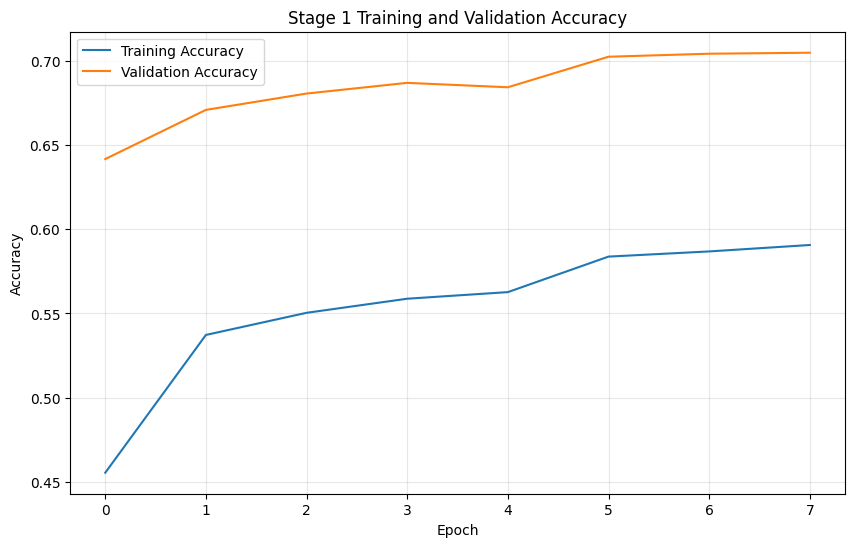

In [ ]:
# STEP 6C: PLOT ACCURACY


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_stage1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Stage 1 Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

## 6.3 Training and Validation Loss

Loss measures how different the model's predictions are from the correct
Food-101 labels.

The validation loss is especially useful when monitoring overfitting.

The best model checkpoint was already saved during training whenever validation
loss improved.

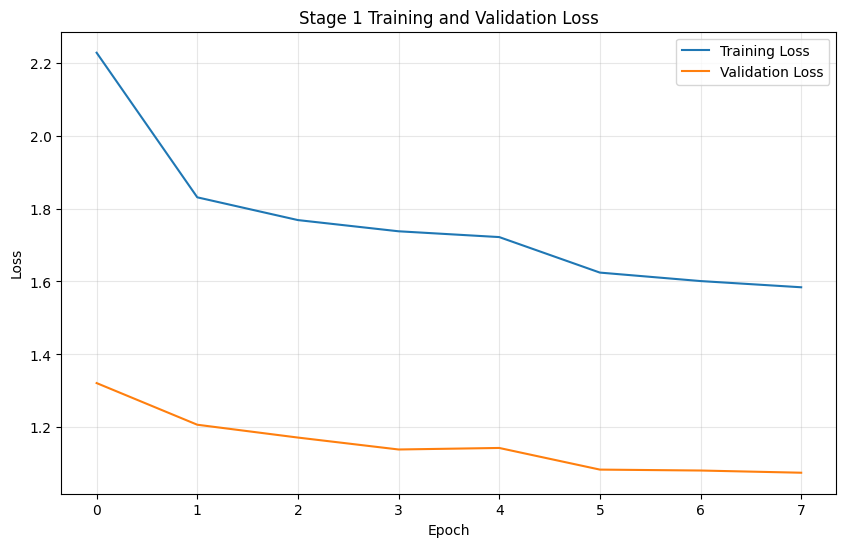

In [ ]:
# STEP 6D: PLOT LOSS

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_stage1.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_stage1.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Stage 1 Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

## 6.4 Load the Best Stage 1 Model

During Stage 1 training, ModelCheckpoint saved the model whenever validation
loss improved.

Rather than assuming that the final epoch is the best model, we explicitly
load the saved best checkpoint.

This gives us the strongest Stage 1 model as the starting point for
fine tuning.

In [ ]:
# STEP 6E: LOAD BEST STAGE 1 CHECKPOINT

best_stage1_path = os.path.join(
    CHECKPOINT_DIR,
    "food101_stage1_best.keras"
)


# Check that the checkpoint exists.

if not os.path.exists(
    best_stage1_path
):

    raise FileNotFoundError(
        "Best Stage 1 checkpoint was not found:\n"
        + best_stage1_path
    )


print(
    "Loading best Stage 1 model..."
)


# Load the saved model.

model = keras.models.load_model(
    best_stage1_path
)


print(
    "Best Stage 1 model loaded successfully."
)


# Display its validation performance.

print(
    "\nBest Stage 1 validation accuracy:",
    f"{best_stage1_accuracy * 100:.2f}%"
)

Loading best Stage 1 model...
Best Stage 1 model loaded successfully.

Best Stage 1 validation accuracy: 70.48%


# 7. Stage 2 : Fine Tuning EfficientNetV2B0

The best model obtained during Stage 1 is now used as the starting point for
fine-tuning.

During Stage 1, the EfficientNetV2B0 backbone was frozen.

During Stage 2, only the later portion of the backbone is made trainable.

The earlier layers contain more general visual features such as edges and basic
textures. These features are useful for many image recognition tasks and do
not need to be changed substantially.

The later layers contain more task specific visual representations. Fine tuning
these layers allows the model to adapt better to food specific characteristics.

A much smaller learning rate is used during fine tuning to avoid making large
changes to the pretrained weights.

In [ ]:
# STEP 7A: PREPARE EFFICIENTNETV2B0 FOR FINE-TUNING

# Locate the EfficientNetV2B0 backbone inside our model.
#
# The backbone was named "efficientnetv2-b0" by Keras.
# We search for it rather than assuming a specific layer index.

base_model = None

for layer in model.layers:

    if isinstance(
        layer,
        keras.Model
    ) and "efficientnetv2" in layer.name.lower():

        base_model = layer
        break


# Verify that the backbone was found.

if base_model is None:

    raise RuntimeError(
        "EfficientNetV2B0 backbone could not be found "
        "inside the model."
    )


print(
    "Backbone found:",
    base_model.name
)

Backbone found: efficientnetv2-b0


## 7.1 Selective Layer Unfreezing

EfficientNetV2B0 contains many layers.

Instead of making the entire network trainable, approximately the final 30%
of the backbone layers will be fine tuned.

This is a compromise between:

- retaining useful pretrained ImageNet features,
- allowing food specific adaptation,
- reducing computational requirements,
- and reducing the risk of catastrophic changes to the pretrained
  representation.

Batch normalization layers remain frozen.

This is intentional because changing BatchNormalization statistics during
fine tuning with relatively small batches can make training unstable.

In [ ]:
# STEP 7B: UNFREEZE ONLY THE UPPER PORTION

# First freeze the entire backbone.

base_model.trainable = True


# Calculate the point at which the final 30% of layers begin.

total_backbone_layers = len(
    base_model.layers
)

fine_tune_start = int(
    total_backbone_layers * 0.70
)


print(
    "Total backbone layers:",
    total_backbone_layers
)

print(
    "Fine-tuning starts at layer:",
    fine_tune_start
)


# Freeze earlier layers and BatchNormalization layers.

for index, layer in enumerate(
    base_model.layers
):

    # Keep the earlier 70% frozen.
    if index < fine_tune_start:

        layer.trainable = False

    # Keep BatchNormalization layers frozen.
    elif isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

    # Only selected upper layers are trainable.
    else:

        layer.trainable = True


# Count trainable and frozen backbone layers.

trainable_backbone_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

frozen_backbone_layers = (
    total_backbone_layers
    - trainable_backbone_layers
)


print(
    "\nTrainable backbone layers:",
    trainable_backbone_layers
)

print(
    "Frozen backbone layers:",
    frozen_backbone_layers
)

Total backbone layers: 270
Fine-tuning starts at layer: 189

Trainable backbone layers: 64
Frozen backbone layers: 206


## 7.2 Recompile After Changing Trainable Layers

The model must be recompiled after changing which layers are trainable.

A much smaller learning rate is used for finebtuning.

Stage 1 used a learning rate of 0.001.

Stage 2 uses:

0.00001

This is intentionally much smaller.

The purpose of fine tuning is not to relearn the entire visual representation.
Instead, the pretrained features are adjusted gradually to become more useful
for food classification.

In [ ]:
# STEP 7C: COMPILE FOR FINE TUNING

fine_tune_optimizer = keras.optimizers.AdamW(

    learning_rate=1e-5,

    weight_decay=1e-5
)


# Recompile the model after changing trainable layers.

model.compile(

    optimizer=fine_tune_optimizer,

    loss=keras.losses.SparseCategoricalCrossentropy(),

    metrics=[

        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),

        keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )

    ]
)


print(
    "Model recompiled for fine-tuning."
)

print(
    "Fine-tuning learning rate:",
    1e-5
)

Model recompiled for fine-tuning.
Fine-tuning learning rate: 1e-05


## 7.3 Fine Tuning Callbacks

A separate checkpoint is used for Stage 2 so that the best fine tuned model
is preserved.

The patience values are intentionally conservative.

Fine tuning may produce smaller improvements than Stage 1, so we give the model
some time to improve before stopping.

In [ ]:
# STEP 7D: FINE TUNING CALLBACKS

fine_tune_checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "food101_finetuned_best.keras"
)


fine_tune_checkpoint = keras.callbacks.ModelCheckpoint(

    filepath=fine_tune_checkpoint_path,

    monitor="val_loss",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)


fine_tune_early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True,

    verbose=1
)


fine_tune_reduce_lr = keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=1,

    min_lr=1e-7,

    verbose=1
)


callbacks_stage2 = [

    fine_tune_checkpoint,

    fine_tune_early_stopping,

    fine_tune_reduce_lr

]


print(
    "Fine-tuning callbacks created successfully."
)

Fine-tuning callbacks created successfully.


## 7.4 Verify the Fine Tuning Configuration

Before starting Stage 2, the configuration is checked one final time.

The model should now contain:

- The best Stage 1 weights
- The Food-101 classification head
- The upper portion of EfficientNetV2B0 trainable
- Earlier EfficientNet layers frozen
- BatchNormalization layers frozen
- A learning rate of 0.00001

This verification helps prevent accidentally fine tuning the entire network.

In [ ]:
# STEP 7E: VERIFY FINETUNING CONFIGURATION

trainable_parameters = np.sum(
    [
        np.prod(variable.shape)
        for variable in model.trainable_variables
    ]
)


total_parameters = np.sum(
    [
        np.prod(variable.shape)
        for variable in model.variables
    ]
)


print("=" * 60)
print("FINE-TUNING CONFIGURATION")
print("=" * 60)

print(
    "Backbone:",
    base_model.name
)

print(
    "Total model parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Learning rate:",
    1e-5
)

print(
    "Trainable backbone layers:",
    trainable_backbone_layers
)

print(
    "Frozen backbone layers:",
    frozen_backbone_layers
)

print("=" * 60)

FINE-TUNING CONFIGURATION
Backbone: efficientnetv2-b0
Total model parameters: 6,048,735
Trainable parameters: 3,197,781
Learning rate: 1e-05
Trainable backbone layers: 64
Frozen backbone layers: 206


# 8. Stage 2 : Fine Tune the Food Classification Model

The best Stage 1 model is now fine tuned using a small learning rate.

Only the selected upper layers of EfficientNetV2B0 are trainable.

The earlier layers remain frozen because they contain general visual features
that were already learned from ImageNet.

The fine tuning stage uses a maximum of 8 epochs.

Early stopping will terminate training automatically if validation performance
stops improving.

The best fine tuned model will be saved automatically.

In [ ]:
# STEP 8A: START STAGE 2 FINE-TUNING

print("=" * 60)
print("STARTING STAGE 2 FINE-TUNING")
print("=" * 60)

print(
    "\nModel:",
    model.name
)

print(
    "Backbone:",
    base_model.name
)

print(
    "Trainable backbone layers:",
    trainable_backbone_layers
)

print(
    "Frozen backbone layers:",
    frozen_backbone_layers
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Learning rate:",
    1e-5
)

print(
    "\nFine-tuning begins...\n"
)



# Continue training from the BEST Stage 1 model.
#
# We are NOT starting from random weights.
#
# Only the selected upper EfficientNetV2B0 layers and the
# Food-101 classification head are trainable.

history_stage2 = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=8,

    callbacks=callbacks_stage2,

    verbose=1
)


print("\n")
print("=" * 60)
print("STAGE 2 FINE-TUNING COMPLETE")
print("=" * 60)

STARTING STAGE 2 FINE-TUNING

Model: Food101_EfficientNetV2B0
Backbone: efficientnetv2-b0
Trainable backbone layers: 64
Frozen backbone layers: 206
Batch size: 16
Learning rate: 1e-05

Fine-tuning begins...

Epoch 1/8
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6229 - loss: 1.4483 - top_5_accuracy: 0.8541
Epoch 1: val_loss improved from None to 0.98200, saving model to /content/food101_checkpoints/food101_finetuned_best.keras

Epoch 1: finished saving model to /content/food101_checkpoints/food101_finetuned_best.keras
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 455s 91ms/step - accuracy: 0.6316 - loss: 1.4112 - top_5_accuracy: 0.8603 - val_accuracy: 0.7329 - val_loss: 0.9820 - val_top_5_accuracy: 0.9260 - learning_rate: 1.0000e-05
Epoch 2/8
4734/4735 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6468 - loss: 1.3518 - top_5_accuracy: 0.8708
Epoch 2: val_loss improved from 0.98200 to 0.94139, saving model to /content/food101_checkpoints/food101_finetuned_best.keras

Epoch 2: finished s

## 8.1 Inspect Fine Tuning Results

The Stage 2 history is examined to determine whether fine tuning improved the
model.

We compare validation accuracy from Stage 2 with the best Stage 1 validation
accuracy.

An improvement indicates that adapting the pretrained features to the
Food-101 domain was beneficial.

If fine tuning does not improve the validation result, the Stage 1 model remains
available as a backup.

In [ ]:
# STEP 8B: INSPECT STAGE 2 RESULTS

history_stage2_df = pd.DataFrame(
    history_stage2.history
)


print("Stage 2 Training History")
print("=" * 60)

display(
    history_stage2_df
)


# Find best Stage 2 validation accuracy.

best_stage2_epoch = (
    history_stage2_df[
        "val_accuracy"
    ].idxmax()
)


best_stage2_accuracy = (
    history_stage2_df.loc[
        best_stage2_epoch,
        "val_accuracy"
    ]
)


print(
    "\nBest Stage 2 validation accuracy:"
)

print(
    f"{best_stage2_accuracy * 100:.2f}%"
)

print(
    "Best Stage 2 epoch:",
    best_stage2_epoch + 1
)


# Compare Stage 1 and Stage 2.

print(
    "\nBest Stage 1 validation accuracy:"
)

print(
    f"{best_stage1_accuracy * 100:.2f}%"
)


improvement = (
    best_stage2_accuracy
    - best_stage1_accuracy
)


print(
    "\nChange after fine-tuning:"
)

print(
    f"{improvement * 100:+.2f} percentage points"
)

Stage 2 Training History


,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,0.631578,1.411164,0.860290,0.732871,0.981998,0.925980,0.00001
1,0.652752,1.324174,0.875287,0.740277,0.941392,0.929584,0.00001
2,0.662997,1.276740,0.880634,0.747604,0.916183,0.932871,0.00001
3,0.674785,1.228395,0.887696,0.751406,0.896916,0.934455,0.00001
4,0.682561,1.199727,0.890653,0.756317,0.874927,0.936436,0.00001
5,0.688198,1.167844,0.897690,0.760911,0.857806,0.938178,0.00001
6,0.694231,1.141059,0.899010,0.764911,0.844081,0.939564,0.00001
7,0.700726,1.118683,0.903908,0.767010,0.834956,0.940079,0.00001



Best Stage 2 validation accuracy:
76.70%
Best Stage 2 epoch: 8

Best Stage 1 validation accuracy:
70.48%

Change after fine-tuning:
+6.22 percentage points


## 8.2 Plot Fine Tuning Accuracy

The Stage 2 training and validation accuracy are plotted to visualize the
effect of finetuning..

The validation curve is particularly important because our objective is not
simply to increase training accuracy.

The goal is to improve generalization to unseen food images.

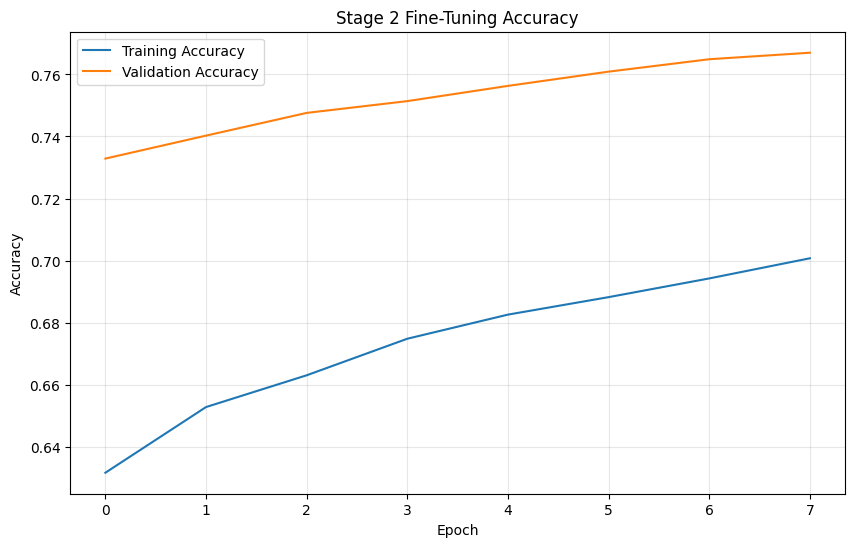

In [ ]:
# STEP 8C: PLOT STAGE 2 ACCURACY

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_stage2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_stage2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Stage 2 Fine-Tuning Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

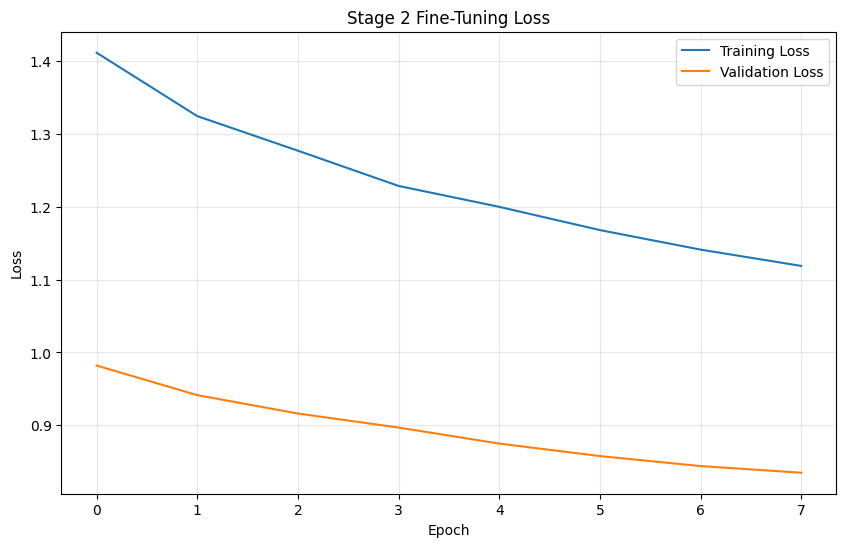

In [ ]:
# STEP 8D: PLOT STAGE 2 LOSS

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_stage2.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_stage2.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Stage 2 Fine-Tuning Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.show()

## 8.3 Load the Best Fine Tuned Model

The checkpoint callback saved the model with the lowest validation loss.

We explicitly load this model instead of automatically assuming that the final
epoch produced the best result.

This ensures that the final model used by the project corresponds to the best
validation performance observed during fine tuning.

In [ ]:
# STEP 8E: LOAD BEST FINE-TUNED MODEL

if not os.path.exists(
    fine_tune_checkpoint_path
):

    raise FileNotFoundError(
        "The best fine-tuned model was not found:\n"
        + fine_tune_checkpoint_path
    )


print(
    "Loading best fine-tuned model..."
)


model = keras.models.load_model(
    fine_tune_checkpoint_path
)


print(
    "Best fine-tuned model loaded successfully."
)


# Display the validation result obtained during training.

print(
    "\nBest Stage 2 validation accuracy:",
    f"{best_stage2_accuracy * 100:.2f}%"
)

Loading best fine-tuned model...
Best fine-tuned model loaded successfully.

Best Stage 2 validation accuracy: 76.70%


# 9. Model Evaluation

The fine tuned model is now evaluated on the Food-101 validation dataset.

The validation dataset was not used to directly update the model weights, so it
provides an estimate of how well the trained model generalizes to unseen images.

The evaluation includes:

- Overall validation loss
- Top-1 accuracy
- Top-5 accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

Top1 accuracy measures whether the model's highest probability prediction is
the correct food category.

Top5 accuracy measures whether the correct food category appears among the
five highest probability predictions.

Precision, recall and F1 score provide additional information about performance
across the 101 individual food categories.

In [ ]:
# STEP 9A: EVALUATE THE FINAL MODEL

print("=" * 60)
print("EVALUATING FINAL FOOD-101 MODEL")
print("=" * 60)

evaluation_results = model.evaluate(
    validation_ds,
    verbose=1,
    return_dict=True
)

print("\nEvaluation Results")
print("=" * 60)

for metric_name, metric_value in evaluation_results.items():

    print(
        f"{metric_name}: {metric_value:.4f}"
    )

print("=" * 60)

EVALUATING FINAL FOOD-101 MODEL
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 107s 65ms/step - accuracy: 0.7670 - loss: 0.8350 - top_5_accuracy: 0.9401

Evaluation Results
accuracy: 0.7670
loss: 0.8350
top_5_accuracy: 0.9401


## 9.1 Generate Predictions for the Validation Dataset

To calculate precision, recall and F1-score, we need the predicted class for
each validation image.

The model produces a probability distribution over all 101 Food-101 classes.

For each image, the class with the highest probability is selected as the
model's final prediction.

The true labels are collected from the validation dataset and compared with
these predictions.

In [ ]:
# STEP 9B: GENERATE VALIDATION PREDICTIONS

print("Generating validation predictions...")

all_true_labels = []
all_predicted_labels = []

all_prediction_probabilities = []


# Process the validation dataset batch by batch.
#
# We do NOT convert the entire image dataset into NumPy arrays.
# Only the predictions and labels are collected.

for images, labels in validation_ds:

    # Get probability predictions for the current batch.
    probabilities = model.predict(
        images,
        verbose=0
    )

    # Highest-probability class = final prediction.
    predictions = np.argmax(
        probabilities,
        axis=1
    )

    # Store labels and predictions.
    all_true_labels.extend(
        labels.numpy()
    )

    all_predicted_labels.extend(
        predictions
    )

    all_prediction_probabilities.append(
        probabilities
    )


# Convert labels and predictions into NumPy arrays.

all_true_labels = np.array(
    all_true_labels
)

all_predicted_labels = np.array(
    all_predicted_labels
)

all_prediction_probabilities = np.concatenate(
    all_prediction_probabilities,
    axis=0
)


print(
    "Prediction generation complete."
)

print(
    "Number of validation predictions:",
    len(all_predicted_labels)
)

print(
    "Number of true validation labels:",
    len(all_true_labels)
)

Generating validation predictions...
Prediction generation complete.
Number of validation predictions: 25250
Number of true validation labels: 25250


## 9.2 Precision, Recall and F1 Score

Precision, recall and F1 score are calculated using the predictions generated
for all validation images.

Because Food-101 contains 101 categories, macro averaging is used.

Macro averaging calculates the metric independently for each food category
and then calculates the unweighted average across all categories.

This gives each food category equal importance, rather than allowing categories
with more successful predictions to dominate the overall score.

In [ ]:
# STEP 9C: CALCULATE PRECISION, RECALL AND F1-SCORE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Overall top-1 accuracy.

top1_accuracy = accuracy_score(
    all_true_labels,
    all_predicted_labels
)


# Macro precision.

macro_precision = precision_score(

    all_true_labels,

    all_predicted_labels,

    average="macro",

    zero_division=0
)


# Macro recall

macro_recall = recall_score(

    all_true_labels,

    all_predicted_labels,

    average="macro",

    zero_division=0
)


# Macro F1-score.

macro_f1 = f1_score(

    all_true_labels,

    all_predicted_labels,

    average="macro",

    zero_division=0
)


print("=" * 60)
print("FINAL MODEL METRICS")
print("=" * 60)

print(
    f"Top-1 Accuracy : {top1_accuracy * 100:.2f}%"
)

print(
    f"Macro Precision: {macro_precision * 100:.2f}%"
)

print(
    f"Macro Recall   : {macro_recall * 100:.2f}%"
)

print(
    f"Macro F1-Score : {macro_f1 * 100:.2f}%"
)

print("=" * 60)

FINAL MODEL METRICS
Top-1 Accuracy : 76.70%
Macro Precision: 77.12%
Macro Recall   : 76.70%
Macro F1-Score : 76.65%


## 9.3 Confusion Matrix

A confusion matrix shows how the model's predictions are distributed across
the 101 food categories.

The rows represent the actual food categories.

The columns represent the predicted categories.

Strong diagonal values indicate correct predictions.

Off-diagonal values show cases where the model confused one food category with
another.

This is particularly useful for Food-101 because some categories have visually
similar characteristics.

In [ ]:
# STEP 9D: CREATE CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(

    all_true_labels,

    all_predicted_labels,

    labels=np.arange(
        NUM_CLASSES
    )
)


print(
    "Confusion matrix shape:",
    conf_matrix.shape
)

Confusion matrix shape: (101, 101)


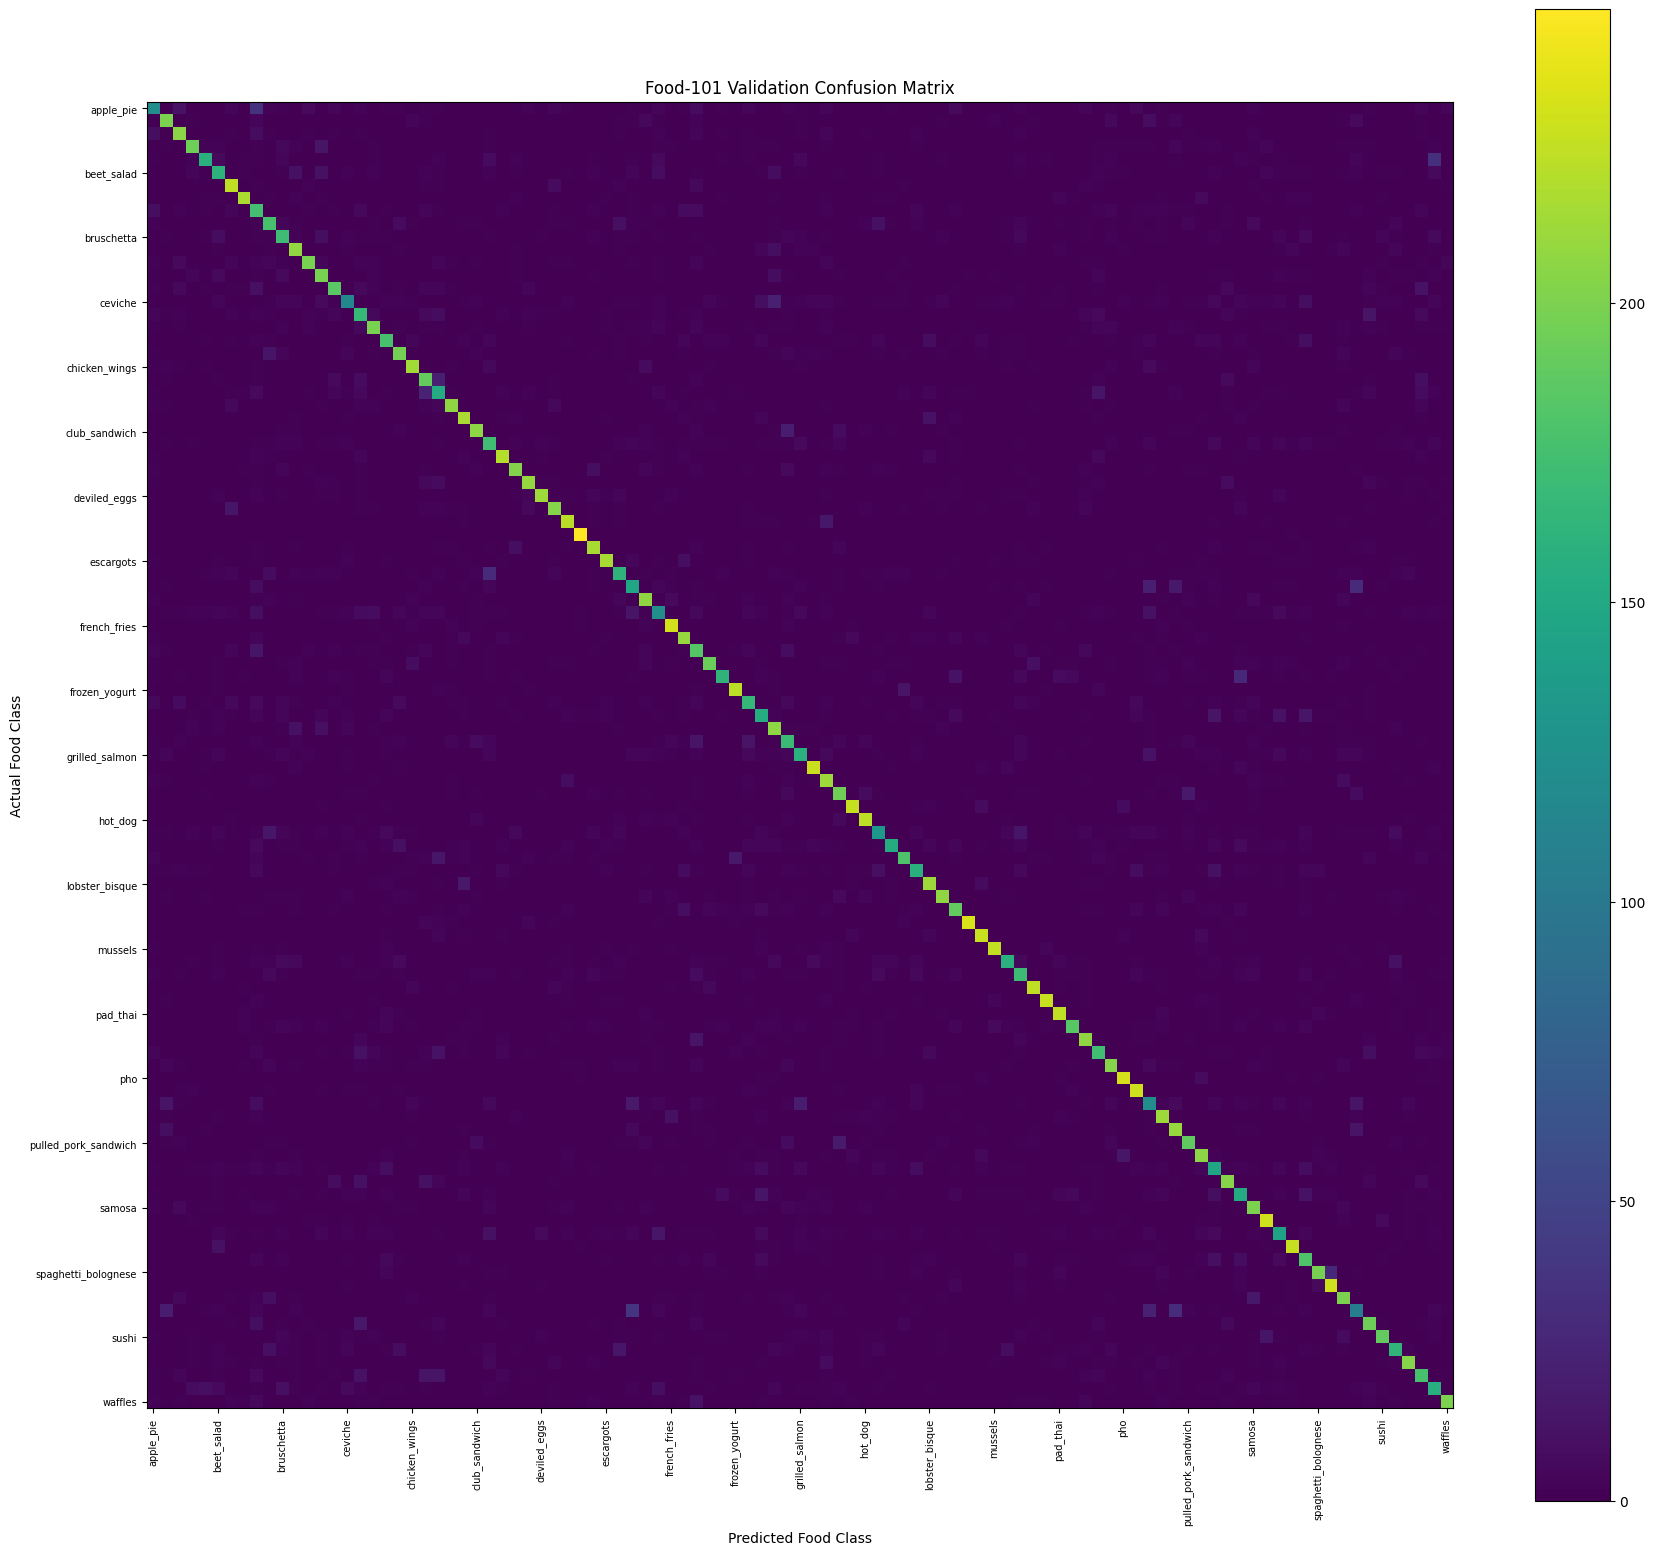

In [ ]:
# STEP 9E: DISPLAY CONFUSION MATRIX

plt.figure(
    figsize=(18, 16)
)

plt.imshow(
    conf_matrix,
    interpolation="nearest"
)

plt.title(
    "Food-101 Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted Food Class"
)

plt.ylabel(
    "Actual Food Class"
)

plt.colorbar()

# We have 101 categories, so displaying every class name on
# the axes would make the figure difficult to read.
#
# Tick labels are shown at regular intervals.

tick_positions = np.arange(
    0,
    NUM_CLASSES,
    5
)

plt.xticks(
    tick_positions,
    [
        class_names[i]
        for i in tick_positions
    ],
    rotation=90,
    fontsize=7
)

plt.yticks(
    tick_positions,
    [
        class_names[i]
        for i in tick_positions
    ],
    fontsize=7
)

plt.tight_layout()

plt.show()

## 9.4 Most Common Food Confusions

The confusion matrix can also be used to identify the food categories that
the model confuses most frequently.

This provides a more meaningful interpretation of model limitations than
accuracy alone.

For example, if two visually similar foods are frequently confused, this may
indicate that the image classifier has difficulty distinguishing subtle visual
differences between those categories.

In [ ]:
# STEP 9F: FIND MOST COMMON CONFUSIONS

# Make a copy so that correct predictions on the diagonal
# can be ignored.

confusion_without_diagonal = conf_matrix.copy()

np.fill_diagonal(
    confusion_without_diagonal,
    0
)


# Find the 15 largest off-diagonal confusion counts.

top_confusions = []

for _ in range(15):

    actual_index, predicted_index = np.unravel_index(

        np.argmax(
            confusion_without_diagonal
        ),

        confusion_without_diagonal.shape
    )

    count = confusion_without_diagonal[
        actual_index,
        predicted_index
    ]

    if count == 0:
        break

    top_confusions.append(
        (
            class_names[actual_index],
            class_names[predicted_index],
            int(count)
        )
    )

    # Prevent selecting the same confusion again.
    confusion_without_diagonal[
        actual_index,
        predicted_index
    ] = 0


print("=" * 70)
print("MOST COMMON FOOD-101 CONFUSIONS")
print("=" * 70)

for actual, predicted, count in top_confusions:

    print(
        f"Actual: {actual:<25} "
        f"Predicted: {predicted:<25} "
        f"Count: {count}"
    )

print("=" * 70)

MOST COMMON FOOD-101 CONFUSIONS
Actual: steak                     Predicted: filet_mignon              Count: 38
Actual: apple_pie                 Predicted: bread_pudding             Count: 36
Actual: beef_tartare              Predicted: tuna_tartare              Count: 34
Actual: steak                     Predicted: prime_rib                 Count: 32
Actual: falafel                   Predicted: crab_cakes                Count: 30
Actual: filet_mignon              Predicted: steak                     Count: 30
Actual: fried_rice                Predicted: risotto                   Count: 29
Actual: spaghetti_bolognese       Predicted: spaghetti_carbonara       Count: 28
Actual: chocolate_mousse          Predicted: chocolate_cake            Count: 25
Actual: steak                     Predicted: pork_chop                 Count: 23
Actual: ceviche                   Predicted: greek_salad               Count: 22
Actual: chocolate_cake            Predicted: chocolate_mousse          Count:

## 9.5 Evaluation Interpretation

The evaluation metrics provide different views of model performance.

Accuracy measures the percentage of validation images for which the top
prediction is correct.

Precision measures how often a predicted food category is correct.

Recall measures how effectively the model identifies images belonging to a
food category.

F1-score provides a balance between precision and recall.

The confusion matrix provides additional information about which specific
foods are difficult for the model to distinguish.

These results will be used in the final report to discuss both the strengths
and limitations of the proposed Food Calorie Prediction System.

# 10. Save the Final Trained Model

The best fine tuned model is now saved permanently.

Saving the model is important because training Food-101 is computationally
expensive and should not be repeated every time the system is used.

The complete Keras model is saved, including:

- Model architecture
- Learned weights
- Classification layer
- Model configuration

The model will be stored in Google Drive so that it can be loaded again instead of training again and again

After this step, the saved model can be used directly for food image
prediction without retraining.

In [ ]:
# STEP 10A: MOUNT GOOGLE DRIVE

from google.colab import drive

print("Connecting to Google Drive...")

drive.mount(
    "/content/drive"
)

print(
    "Google Drive mounted successfully."
)

Connecting to Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# STEP 10B: CREATE PROJECT FOLDER IN GOOGLE DRIVE

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "Food_Calorie_Prediction_System"
)


os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


print(
    "Project folder:"
)

print(
    MODEL_DIR
)

Project folder:
/content/drive/MyDrive/Food_Calorie_Prediction_System


In [ ]:
# STEP 10C: SAVE FINAL MODEL

FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "food101_efficientnetv2b0_final.keras"
)


print(
    "Saving final model..."
)

print(
    "This may take a little while."
)


model.save(
    FINAL_MODEL_PATH
)


print(
    "\nFinal model saved successfully!"
)

print(
    "Location:"
)

print(
    FINAL_MODEL_PATH
)

Saving final model...
This may take a little while.

Final model saved successfully!
Location:
/content/drive/MyDrive/Food_Calorie_Prediction_System/food101_efficientnetv2b0_final.keras


## 10.1 Save the Food Class Names

The model outputs numbers from 0 to 100.

For example:

42

does not mean anything to the user by itself.

The class name mapping converts that number into the actual Food-101 category.

It is important to save this mapping together with the model so that future
prediction sessions use exactly the same class ordering that was used during
training.

In [ ]:
# STEP 10D: SAVE CLASS NAMES

# Import JSON here so this cell works even after a Colab
# runtime restart.
import json


# Path where the Food-101 class-name mapping will be saved.

CLASS_NAMES_PATH = os.path.join(
    MODEL_DIR,
    "food101_class_names.json"
)


# Save the 101 class names.
#
# The order is extremely important because the model outputs
# class numbers from 0 to 100.

with open(
    CLASS_NAMES_PATH,
    "w"
) as file:

    json.dump(
        class_names,
        file,
        indent=4
    )


print(
    "Food class names saved successfully!"
)

print(
    "Location:"
)

print(
    CLASS_NAMES_PATH
)

Food class names saved successfully!
Location:
/content/drive/MyDrive/Food_Calorie_Prediction_System/food101_class_names.json


## 10.2 Save Project Metadata

Additional information about the trained model is saved separately.
The metadata contains:

- Number of food classes
- Image size
- Model name
- Best Stage 1 validation accuracy
- Best Stage 2 validation accuracy
- Final evaluation metrics

In [ ]:
# STEP 10E: SAVE MODEL METADATA

metadata = {

    "project_name":
        "Food Calorie Prediction System",

    "model_name":
        "EfficientNetV2B0",

    "dataset":
        "Food-101",

    "num_classes":
        int(NUM_CLASSES),

    "image_size":
        int(IMAGE_SIZE),

    "batch_size":
        int(BATCH_SIZE),

    "best_stage1_validation_accuracy":
        float(best_stage1_accuracy),

    "best_stage2_validation_accuracy":
        float(best_stage2_accuracy),

    "top1_accuracy":
        float(top1_accuracy),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1)

}


METADATA_PATH = os.path.join(
    MODEL_DIR,
    "model_metadata.json"
)


with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )


print(
    "Model metadata saved successfully!"
)

print(
    "Location:"
)

print(
    METADATA_PATH
)

Model metadata saved successfully!
Location:
/content/drive/MyDrive/Food_Calorie_Prediction_System/model_metadata.json


In [ ]:
# STEP 10F: VERIFY SAVED PROJECT FILES

print("=" * 60)
print("SAVED PROJECT FILES")
print("=" * 60)


files_to_check = [

    FINAL_MODEL_PATH,

    CLASS_NAMES_PATH,

    METADATA_PATH

]


for file_path in files_to_check:

    exists = os.path.exists(
        file_path
    )

    print(
        "\n",
        os.path.basename(file_path),
        "->",
        "FOUND" if exists else "NOT FOUND"
    )


print("\n" + "=" * 60)

SAVED PROJECT FILES

 food101_efficientnetv2b0_final.keras -> FOUND

 food101_class_names.json -> FOUND

 model_metadata.json -> FOUND



In [ ]:
# STEP 10G: TEST LOADING THE SAVED MODEL

print(
    "Testing saved model..."
)


loaded_model = keras.models.load_model(
    FINAL_MODEL_PATH
)


print(
    "\nSaved model loaded successfully!"
)

print(
    "Model name:",
    loaded_model.name
)

Testing saved model...

Saved model loaded successfully!
Model name: Food101_EfficientNetV2B0


# 11. Food Image Prediction

The trained EfficientNetV2B0 model can now be used to classify a new food
image.

This prediction stage is separate from model training.

The saved .keras model is loaded from Google Drive and used to make
predictions.

The user provides an image of food, and the system:

1. Loads the image
2. Resizes it to 224 × 224 pixels
3. Passes it through the trained model
4. Calculates probabilities for all 101 Food-101 categories
5. Selects the category with the highest probability
6. Displays the predicted food and confidence

In [ ]:

# STEP 11A: LOAD THE SAVED MODEL AND CLASS NAMES

import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras


# Define the saved project location.

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "Food_Calorie_Prediction_System"
)


FINAL_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "food101_efficientnetv2b0_final.keras"
)


CLASS_NAMES_PATH = os.path.join(
    MODEL_DIR,
    "food101_class_names.json"
)


# Check that the files exist before trying to load them.

if not os.path.exists(
    FINAL_MODEL_PATH
):

    raise FileNotFoundError(
        "Saved model was not found:\n"
        + FINAL_MODEL_PATH
    )


if not os.path.exists(
    CLASS_NAMES_PATH
):

    raise FileNotFoundError(
        "Class names file was not found:\n"
        + CLASS_NAMES_PATH
    )


# Load the trained model.
#
# IMPORTANT:
# This does NOT train the model.
# It only restores the model that we already trained.

prediction_model = keras.models.load_model(
    FINAL_MODEL_PATH
)


# Load the Food-101 class names.

with open(
    CLASS_NAMES_PATH,
    "r"
) as file:

    prediction_class_names = json.load(
        file
    )


print(
    "Saved model loaded successfully."
)

print(
    "Number of food classes:",
    len(prediction_class_names)
)

Saved model loaded successfully.
Number of food classes: 101


## 11.1 Prediction Function

The following function accepts the path to an image and returns the predicted
Food-101 category and its confidence.

The same preprocessing used during model development is applied to the uploaded
image.

The image is resized to 224 × 224 pixels because this is the input size used by
EfficientNetV2B0 in our project.

The model returns probabilities for all 101 classes.

The class with the highest probability is selected as the prediction.

In [ ]:
# STEP 11B: CREATE FOOD PREDICTION FUNCTION

def predict_food(
    image_path
):

    # Check that the image exists.

    if not os.path.exists(
        image_path
    ):

        raise FileNotFoundError(
            f"Image not found:\n{image_path}"
        )


    # Load the image.
    #
    # target_size ensures that the image has the same spatial
    # dimensions used during model training.

    image = keras.utils.load_img(

        image_path,

        target_size=(
            224,
            224
        ),

        color_mode="rgb"
    )


    # Convert the PIL image into a NumPy array.


    image_array = keras.utils.img_to_array(
        image
    )


    # Add a batch dimension.
    #
    # Before:
    #     (224, 224, 3)
    #
    # After:
    #     (1, 224, 224, 3)
    #
    # The model expects a batch of images.

    image_array = np.expand_dims(
        image_array,
        axis=0
    )


    # Generate predictions.
    #
    # The model returns 101 probabilities.

    probabilities = prediction_model.predict(
        image_array,
        verbose=0
    )[0]


    # Find the class with the highest probability.

    predicted_index = int(
        np.argmax(
            probabilities
        )
    )


    # Convert the class index into the actual food name.

    predicted_food = (
        prediction_class_names[
            predicted_index
        ]
    )


    # Convert probability to percentage.

    confidence = (
        float(
            probabilities[
                predicted_index
            ]
        )
        * 100
    )


    return (
        predicted_food,
        confidence
    )

## 11.2 Upload a Food Image

Google Colab provides a file upload widget that allows the user to select an
image from their computer so using that.

The uploaded file is temporarily placed in the Colab environment.

The saved Food 101 model is then used to classify the image.

This demonstrates the actual user workflow of the proposed system.

In [ ]:
# STEP 11C: UPLOAD A FOOD IMAGE

from google.colab import files


print(
    "Please upload a food image."
)


uploaded = files.upload()


# Get the name of the uploaded file.

image_path = next(
    iter(uploaded.keys())
)


print(
    "\nUploaded image:"
)

print(
    image_path
)

Please upload a food image.


Saving pizza.jpeg to pizza.jpeg

Uploaded image:
pizza.jpeg


In [ ]:
# STEP 11D: PREDICT THE UPLOADED FOOD

food, confidence = predict_food(
    image_path
)


print("=" * 60)
print("FOOD PREDICTION")
print("=" * 60)

print(
    f"Predicted food : {food}"
)

print(
    f"Confidence     : {confidence:.2f}%"
)

print("=" * 60)

FOOD PREDICTION
Predicted food : pizza
Confidence     : 54.64%


## 11.3 Display the Uploaded Image and Prediction

The prediction result is displayed together with the uploaded image.

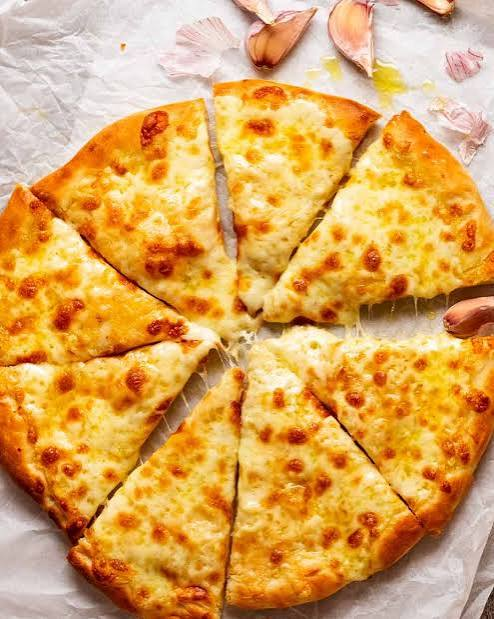


Predicted Food: pizza
Model Confidence: 54.64%


In [ ]:
# STEP 11E: DISPLAY IMAGE AND RESULT

from IPython.display import display


# Display the uploaded image.

display(
    keras.utils.load_img(
        image_path
    )
)


# Display prediction.

print(
    "\nPredicted Food:",
    food
)

print(
    f"Model Confidence: {confidence:.2f}%"
)

# 12. USDA FoodData Central Integration

After the computer vision model identifies the food, the predicted food name
is passed to the USDA FoodData Central database.

The nutrition component searches FoodData Central for a matching food and
retrieves its calorie information.

The overall system therefore consists of two separate components:

Image
  ->
EfficientNetV2B0
  ->
Predicted Food
  ->
USDA FoodData Central
  ->
Nutrition Information
  ->
Estimated Calories

The calorie result should be interpreted as an estimate because the image
classifier identifies the food category but does not directly measure the
weight or portion size of the food.

In [ ]:
# STEP 12A: IMPORT LIBRARIES FOR USDA API

import requests
import getpass
import re

print(
    "USDA API libraries imported successfully."
)

USDA API libraries imported successfully.


## 12.1 USDA API Key

FoodData Central requires an API key for API requests.

In [ ]:
# STEP 12B: ENTER USDA API KEY SECURELY

USDA_API_KEY = getpass.getpass(
    "Enter your USDA FoodData Central API key: "
)


# Basic validation.

if not USDA_API_KEY.strip():

    raise ValueError(
        "No USDA API key was entered."
    )


print(
    "USDA API key received successfully."
)

print(
    "The key is not displayed."
)

Enter your USDA FoodData Central API key: ··········
USDA API key received successfully.
The key is not displayed.


## 12.2 FoodData Central Search

FoodData Central provides a Food Search endpoint that can search for foods
matching a query.

The predicted Food-101 class name will be used as the search query.

For example:

pizza

or

baklava

The returned value is therefore treated as a nutrition reference for the
identified food category.

In [ ]:
# STEP 12C: SEARCH USDA FOODDATA CENTRAL

USDA_SEARCH_URL = (
    "https://api.nal.usda.gov/fdc/v1/foods/search"
)


def search_usda_food(
    food_name,
    page_size=5
):

    # Clean the predicted Food-101 name.
    #
    # Food-101 class names sometimes contain underscores.
    #
    # Example:
    # chicken_curry -> chicken curry

    search_name = food_name.replace(
        "_",
        " "
    )


    # Parameters sent to FoodData Central.

    params = {

        "api_key":
            USDA_API_KEY,

        "query":
            search_name,

        "pageSize":
            page_size

    }


    # Send GET request to USDA.

    response = requests.get(

        USDA_SEARCH_URL,

        params=params,

        timeout=30
    )


    # Stop if USDA returned an error.

    response.raise_for_status()


    # Convert JSON response into a Python dictionary.

    data = response.json()


    # Return matching foods.

    return data.get(
        "foods",
        []
    )

In [ ]:
# STEP 12D: TEST USDA SEARCH

test_food = "pizza"


print(
    f"Searching USDA FoodData Central for: {test_food}"
)


usda_results = search_usda_food(
    test_food
)


print(
    "\nNumber of results returned:",
    len(usda_results)
)


# Display a few returned food descriptions.

for index, result in enumerate(
    usda_results[:5],
    start=1
):

    print(
        f"{index}. "
        f"{result.get('description', 'Unknown food')}"
    )

Searching USDA FoodData Central for: pizza

Number of results returned: 5
1. PIZZA
2. PIZZA
3. PIZZA
4. PIZZA
5. PIZZA


## 12.3 Extract Calorie Information

USDA food records contain nutrient information.

The calorie nutrient is generally identified using nutrient information rather
than assuming that calories are stored in one fixed position in the returned
JSON.

Therefore, the code searches the nutrient list for the nutrient whose name
corresponds to Energy.

The returned energy value is then used as the calorie estimate for the selected
USDA food record.

The exact serving interpretation depends on the USDA record returned by the
search, so the system will display the USDA food description together with the
calorie value rather than presenting the number as an exact measurement of the
uploaded plate.

In [ ]:
# STEP 12E: FIND CALORIE / ENERGY VALUE

def extract_energy_from_food(
    food_record
):

    # Get the nutrient list.

    nutrients = food_record.get(
        "foodNutrients",
        []
    )


    # Search for Energy.
    #
    # USDA records can use names such as:
    # "Energy"
    # or
    # "Energy (Atwater General Factors)"

    for nutrient in nutrients:

        nutrient_name = str(
            nutrient.get(
                "nutrientName",
                ""
            )
        ).lower()


        if (
            "energy" in nutrient_name
        ):

            value = nutrient.get(
                "value"
            )

            unit = nutrient.get(
                "unitName",
                "kcal"
            )


            if value is not None:

                return (
                    float(value),
                    unit
                )


    # If no energy value was found.

    return (
        None,
        None
    )

## 12.4 Create the Complete Nutrition Lookup Function

The following function combines the previous steps.

Input:

Predicted Food-101 class

Output:

- USDA food description
- FDC ID
- Energy/calorie value
- Data source

This function will later be called automatically after the AI predicts the
food.

In [ ]:
# STEP 12F: COMPLETE USDA NUTRITION LOOKUP

def get_usda_calories(
    food_name
):

    # Search USDA FoodData Central.

    results = search_usda_food(
        food_name,
        page_size=10
    )


    # Handle case where no matching food was found.

    if not results:

        return {

            "food_name":
                food_name,

            "usda_food":
                None,

            "fdc_id":
                None,

            "calories":
                None,

            "unit":
                None,

            "message":
                "No matching USDA food record found."

        }


    # Examine returned results until an energy value is found.

    for result in results:

        calories, unit = (
            extract_energy_from_food(
                result
            )
        )


        if calories is not None:

            return {

                "food_name":
                    food_name,

                "usda_food":
                    result.get(
                        "description",
                        "Unknown"
                    ),

                "fdc_id":
                    result.get(
                        "fdcId"
                    ),

                "calories":
                    calories,

                "unit":
                    unit,

                "message":
                    "USDA nutrition value found."

            }


    # Results existed but no energy value was found.


    return {

        "food_name":
            food_name,

        "usda_food":
            results[0].get(
                "description",
                "Unknown"
            ),

        "fdc_id":
            results[0].get(
                "fdcId"
            ),

        "calories":
            None,

        "unit":
            None,

        "message":
            "Food found, but an energy value was not available."

    }

In [ ]:
# STEP 12G: TEST CALORIE LOOKUP

nutrition_result = get_usda_calories(
    "pizza"
)


print("=" * 60)
print("USDA NUTRITION RESULT")
print("=" * 60)

print(
    "Food-101 food:",
    nutrition_result["food_name"]
)

print(
    "USDA food:",
    nutrition_result["usda_food"]
)

print(
    "FDC ID:",
    nutrition_result["fdc_id"]
)

print(
    "Calories:",
    nutrition_result["calories"]
)

print(
    "Unit:",
    nutrition_result["unit"]
)

print(
    "Status:",
    nutrition_result["message"]
)

print("=" * 60)

USDA NUTRITION RESULT
Food-101 food: pizza
USDA food: PIZZA
FDC ID: 482194
Calories: 250.0
Unit: KCAL
Status: USDA nutrition value found.


# 13. Complete Food Calorie Prediction System

The individual components are now combined into one workflow.

The complete system performs the following operations:

1. The user uploads a food image.
2. The saved EfficientNetV2B0 model analyzes the image.
3. The model predicts one of the 101 Food-101 categories.
4. The prediction confidence is calculated.
5. The predicted food name is sent to USDA FoodData Central.
6. A matching USDA food record is selected.
7. The corresponding energy value is retrieved.
8. The final result is displayed to the user.

The trained neural network is only used for food classification.

The calorie estimate comes from the nutrition database.

Therefore, the system does not retrain the model during prediction.

In [ ]:
# STEP 13A: COMPLETE FOOD CALORIE PREDICTION FUNCTION

def predict_food_and_calories(
    image_path
):

    # PART 1: FOOD CLASSIFICATION

    predicted_food, confidence = predict_food(
        image_path
    )


    # PART 2: USDA NUTRITION LOOKUP

    nutrition_result = get_usda_calories(
        predicted_food
    )


    # PART 3: COMBINE RESULTS


    result = {

        "predicted_food":
            predicted_food,

        "confidence":
            confidence,

        "usda_food":
            nutrition_result.get(
                "usda_food"
            ),

        "fdc_id":
            nutrition_result.get(
                "fdc_id"
            ),

        "calories":
            nutrition_result.get(
                "calories"
            ),

        "calorie_unit":
            nutrition_result.get(
                "unit"
            ),

        "nutrition_status":
            nutrition_result.get(
                "message"
            )

    }


    return result

## 13.1 User Image Upload

The user can upload a food image directly through Google Colab.

The uploaded image is then passed automatically to the complete prediction
pipeline.

No training occurs during this process.

In [ ]:
# STEP 13B: UPLOAD IMAGE

from google.colab import files

print(
    "Please upload a food image."
)

uploaded_file = files.upload()


# Get uploaded filename.

uploaded_image_path = next(
    iter(uploaded_file.keys())
)


print(
    "\nImage uploaded successfully:"
)

print(
    uploaded_image_path
)

Please upload a food image.


Saving test3.jpg to test3.jpg

Image uploaded successfully:
test3.jpg


## 13.2 Run the Complete AI Pipeline

The uploaded image is now passed through the complete system.

The workflow is:

Image
↓
EfficientNetV2B0
↓
Food prediction
↓
Confidence
↓
USDA FoodData Central
↓
Calorie information

In [ ]:
# STEP 13C: RUN COMPLETE PREDICTION

print(
    "Analyzing food image..."
)

print(
    "Please wait..."
)


final_result = predict_food_and_calories(
    uploaded_image_path
)


print(
    "\nAnalysis complete."
)

Analyzing food image...
Please wait...

Analysis complete.


## 13.3 Display Final Result

The final output displays the information generated by both AI and the
nutrition database.

The confidence value represents the probability assigned by the image
classification model to its top predicted Food-101 category.

The calorie value is obtained from the matched USDA FoodData Central recordd.

Because the image classifier does not measure physical portion weight, the
calorie value should be treated as an estimate rather than an exact measurement
of the food shown in the photograph..

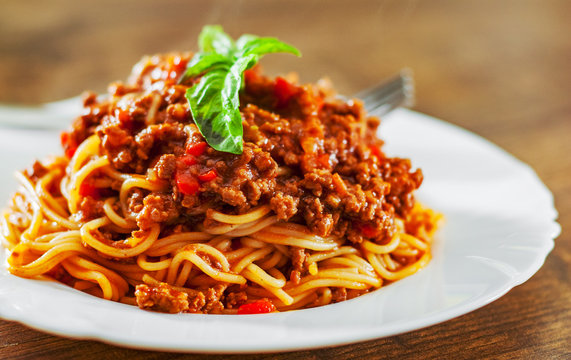

FOOD CALORIE PREDICTION SYSTEM

Predicted Food : spaghetti_bolognese
Confidence     : 98.96%
USDA Food      : SPAGHETTI BOLOGNESE ITALIAN RECIPE SPAGHETTI WITH BEEF BOLOGNESE SAUCE, SPAGHETTI BOLOGNESE
Energy         : 112.00 KCAL


In [ ]:
# STEP 13D: DISPLAY FINAL RESULT

from IPython.display import display
from IPython.display import Image as DisplayImage


# Display uploaded image.

display(
    DisplayImage(
        filename=uploaded_image_path
    )
)


# Extract values.

predicted_food = (
    final_result["predicted_food"]
)

confidence = (
    final_result["confidence"]
)

usda_food = (
    final_result["usda_food"]
)

calories = (
    final_result["calories"]
)

calorie_unit = (
    final_result["calorie_unit"]
)


# Display results.

print("=" * 65)

print(
    "FOOD CALORIE PREDICTION SYSTEM"
)

print("=" * 65)


print(
    f"\nPredicted Food : {predicted_food}"
)


print(
    f"Confidence     : {confidence:.2f}%"
)


if usda_food is not None:

    print(
        f"USDA Food      : {usda_food}"
    )


if calories is not None:

    print(
        f"Energy         : {calories:.2f} {calorie_unit}"
    )

else:

    print(
        "Energy         : Not available"
    )


print("=" * 65)

## 13.4 Add a Confidence Warning

The confidence score should not automatically be interpreted as certainty.

For this reason, the system uses the confidence score to provide a simple
interpretation.

A high confidence prediction is displayed as a stronger prediction.

A low confidence prediction is flagged as uncertain.

This is useful because visually similar foods may produce uncertain
predictions.

In [ ]:
# STEP 13E: CONFIDENCE INTERPRETATION


if confidence >= 80:

    confidence_message = (
        "High-confidence prediction."
    )

elif confidence >= 50:

    confidence_message = (
        "Moderate-confidence prediction."
    )

else:

    confidence_message = (
        "Low-confidence prediction. "
        "The model is uncertain and the result "
        "should be treated cautiously."
    )


print(
    "\nPrediction assessment:"
)

print(
    confidence_message
)


Prediction assessment:
Moderate-confidence prediction.


## 13.5 Display a User-Friendly Summary

The final output is formatted in a way that can be demonstrated during the
project presentation.

In [ ]:
# STEP 13F: FINAL USER-FRIENDLY OUTPUT

print()
print("=" * 70)
print("        FOOD CALORIE PREDICTION SYSTEM")
print("=" * 70)

print()

print(
    f"Food Prediction : {predicted_food}"
)

print(
    f"Confidence      : {confidence:.2f}%"
)

print()

if usda_food:

    print(
        f"USDA Match      : {usda_food}"
    )

else:

    print(
        "USDA Match      : No matching record found"
    )


if calories is not None:

    print(
        f"Estimated Energy: {calories:.2f} {calorie_unit}"
    )

else:

    print(
        "Estimated Energy: Not available"
    )

print()

print(
    confidence_message
)

print()

print(
    "Note: The calorie value is an estimate based on"
)

print(
    "the matched USDA nutrition record. Actual calories"
)

print(
    "depend on ingredients and portion size."
)

print()

print("=" * 70)


        FOOD CALORIE PREDICTION SYSTEM

Food Prediction : pizza
Confidence      : 54.64%

USDA Match      : PIZZA
Estimated Energy: 250.00 KCAL

Moderate-confidence prediction.

Note: The calorie value is an estimate based on
the matched USDA nutrition record. Actual calories
depend on ingredients and portion size.



# 14. Final Demo Section

This section is created separately from the model training part of the notebook
so that the completed system can be tested without training the model again.

The model used in this section has already been trained and saved as a Keras
model.

For the final demonstration, I only need to load the saved model, upload a food
image, predict the food category, and obtain the nutrition information.

The Food 101 dataset is not needed when making a prediction because the model
has already learned the visual features during training.

The final workflow is:

Saved trained model -> Upload food image
-> Food classification ->Prediction confidence ->USDA FoodData Central lookup ->Estimated calorie information

This section is therefore intended to demonstrate how the completed system
would be used by a user.

The earlier sections of this notebook show how the model was developed,
trained, fine tuned, and evaluated.

## 14.1 Loading the Trained Model

The trained model is already available as a saved Keras file.

Instead of training the model again, this section loads the saved model directly.

This makes the final demonstration much faster because the model only needs to
be loaded into memory before making predictions.

The Food 101 dataset and the training process are not required for this step.

In [ ]:
# 14B. FIND AND LOAD THE SAVED TRAINED MODEL

import os
from tensorflow import keras


# Check that Google Drive is available.
#
# If Drive is already mounted, this will simply use it.

if not os.path.exists(
    "/content/drive/MyDrive"
):

    from google.colab import drive

    print(
        "Google Drive is not currently mounted."
    )

    drive.mount(
        "/content/drive"
    )


# Possible locations where the model may have been saved.
#
# The first location was the filename we used earlier in the
# project.
#
# The second location was the newer project-folder structure.

possible_model_paths = [

    "/content/drive/MyDrive/food101_model.keras",

    "/content/drive/MyDrive/Food_Calorie_Prediction_System/"
    "food101_efficientnetv2b0_final.keras",

    "/content/drive/MyDrive/Food_Calorie_Prediction_System/"
    "models/food101_efficientnetv2b0_final.keras"

]


# Search for the existing model.

FINAL_MODEL_PATH = None


print(
    "Searching for the saved trained model..."
)


for path in possible_model_paths:

    print(
        "\nChecking:"
    )

    print(
        path
    )

    if os.path.exists(path):

        FINAL_MODEL_PATH = path

        print(
            "Model found!"
        )

        break


# Stop if none of the expected locations contains the model.

if FINAL_MODEL_PATH is None:

    raise FileNotFoundError(

        "\nThe trained model could not be found "
        "in the expected Google Drive locations.\n\n"

        "The notebook has NOT started training again.\n\n"

        "Please check your Google Drive for the file "
        "food101_model.keras."

    )


# Load the existing trained model.
#
# IMPORTANT:
# keras.models.load_model() only restores the trained model.
#
# It does NOT train the model.

print(
    "\nLoading the saved model..."
)


prediction_model = keras.models.load_model(
    FINAL_MODEL_PATH
)


print(
    "\nSaved model loaded successfully!"
)


print(
    "Model location:"
)

print(
    FINAL_MODEL_PATH
)


print(
    "\nThe model is ready for prediction."
)

Searching for the saved trained model...

Checking:
/content/drive/MyDrive/food101_model.keras

Checking:
/content/drive/MyDrive/Food_Calorie_Prediction_System/food101_efficientnetv2b0_final.keras
Model found!

Loading the saved model...

Saved model loaded successfully!
Model location:
/content/drive/MyDrive/Food_Calorie_Prediction_System/food101_efficientnetv2b0_final.keras

The model is ready for prediction.


## 14.2 Loading the Food 101 Class Names

The trained model produces a numerical class index for each prediction.

For example, the model may return class number 42.

The class names file converts this numerical index into the actual food name.

The class name order must be the same as the order used during model training.

This file is loaded separately so that the prediction section can work without
loading the Food 101 dataset again.

In [ ]:
# 14C. LOAD FOOD 101 CLASS NAMES

import json


# The class names were saved when the trained model was saved.
#
# First, check the project folder location.

possible_class_name_paths = [

    "/content/drive/MyDrive/"
    "Food_Calorie_Prediction_System/"
    "food101_class_names.json",

    "/content/drive/MyDrive/"
    "Food_Calorie_Prediction_System/"
    "config/"
    "food101_class_names.json"

]


# Find the existing class names file.

CLASS_NAMES_PATH = None


print(
    "Searching for the saved Food 101 class names..."
)


for path in possible_class_name_paths:

    print(
        "\nChecking:"
    )

    print(
        path
    )

    if os.path.exists(path):

        CLASS_NAMES_PATH = path

        print(
            "Class names file found!"
        )

        break



# Stop if the file cannot be found.

if CLASS_NAMES_PATH is None:

    raise FileNotFoundError(

        "\nThe Food 101 class names file could not be found.\n\n"

        "Expected file:\n"
        "food101_class_names.json\n\n"

        "The trained model itself has already been loaded, "
        "so no training is required."

    )


# Load the class names.

with open(
    CLASS_NAMES_PATH,
    "r"
) as file:

    prediction_class_names = json.load(
        file
    )


# Verify the number of classes.
#
# Food 101 contains 101 food categories.

print(
    "\nClass names loaded successfully."
)

print(
    "Number of food classes:",
    len(prediction_class_names)
)


# Display a few examples to verify the mapping.

print(
    "\nFirst five food classes:"
)

for index, food_name in enumerate(
    prediction_class_names[:5]
):

    print(
        f"{index}: {food_name}"
    )

Searching for the saved Food 101 class names...

Checking:
/content/drive/MyDrive/Food_Calorie_Prediction_System/food101_class_names.json
Class names file found!

Class names loaded successfully.
Number of food classes: 101

First five food classes:
0: apple_pie
1: baby_back_ribs
2: baklava
3: beef_carpaccio
4: beef_tartare


## 14.3 Creating the Food Prediction Function

The saved model and the saved Food 101 class names are now available.

I will use them to create a separate prediction function for the final
demonstration.

The function takes the path of an uploaded food image as input.

The image is resized to 224 by 224 pixels because this was the input size used
when training the model.

The trained model then predicts probabilities for all 101 food categories.

The category with the highest probability is selected as the predicted food,
and its probability is converted into a percentage to show the model's
confidence.

No training is performed in this function.

In [ ]:
# 14D. FINAL FOOD PREDICTION FUNCTION

def predict_food_final(
    image_path
):

    # Check that the uploaded image exists.

    if not os.path.exists(
        image_path
    ):

        raise FileNotFoundError(
            f"The image could not be found:\n{image_path}"
        )


    # Load the image and resize it to the same size used
    # during model training.

    image = keras.utils.load_img(

        image_path,

        target_size=(
            224,
            224
        ),

        color_mode="rgb"
    )


    # Convert the image into a numerical array.

    image_array = keras.utils.img_to_array(
        image
    )


    # Add a batch dimension.
    #
    # Original:
    # (224, 224, 3)
    #
    # Required by the model:
    # (1, 224, 224, 3)

    image_array = np.expand_dims(
        image_array,
        axis=0
    )


    # Ask the saved model to make a prediction.
    #
    # This only performs inference.
    # The model is not trained or updated.

    probabilities = prediction_model.predict(

        image_array,

        verbose=0
    )[0]


    # Find the class with the highest probability.

    predicted_index = int(
        np.argmax(
            probabilities
        )
    )


    # Convert the numerical class index into the actual
    # Food 101 category.

    predicted_food = (
        prediction_class_names[
            predicted_index
        ]
    )


    # Convert the prediction probability into a percentage.

    confidence = (

        float(
            probabilities[
                predicted_index
            ]
        )
        * 100
    )


    # Return the food name and confidence.

    return (
        predicted_food,
        confidence
    )

## 14.4 Uploading a Food Image

The user can upload an image of a food item from their computer.

The uploaded image will be used as the input to the trained model.

Only the uploaded image is processed at this stage. The Food 101 training
dataset is not downloaded and the model is not trained again.

In [ ]:
# 14E. UPLOAD A FOOD IMAGE


from google.colab import files


# Ask the user to upload an image.

print(
    "Please upload an image of food."
)


uploaded_files = files.upload()


# Get the name of the uploaded file.

image_path = next(
    iter(uploaded_files.keys())
)


print(
    "\nImage uploaded successfully."
)

print(
    "File:",
    image_path
)

Please upload an image of food.


Saving test3.jpg to test3 (1).jpg

Image uploaded successfully.
File: test3 (1).jpg


## 14.5 Predicting the Food

The uploaded image is now passed through the trained EfficientNetV2B0 model.

The model returns probabilities for all 101 Food 101 categories.

The category with the highest probability is selected as the predicted food.

The confidence value shows the probability assigned to that prediction.

This step only uses the trained model for prediction. No additional training is
performed.

In [ ]:
import numpy as np# 14F. PREDICT THE UPLOADED FOOD

print(
    "Analyzing the uploaded image..."
)


# Use the saved model to predict the food.

predicted_food, confidence = predict_food_final(
    image_path
)



# Display the prediction.


print()
print("=" * 60)

print(
    "FOOD CLASSIFICATION RESULT"
)

print("=" * 60)

print(
    f"Predicted food : {predicted_food}"
)

print(
    f"Confidence     : {confidence:.2f}%"
)

print("=" * 60)

Analyzing the uploaded image...

FOOD CLASSIFICATION RESULT
Predicted food : spaghetti_bolognese
Confidence     : 98.96%


## 14.6 USDA FoodData Central Connection

After the model identifies the food, the predicted food name is sent to USDA
FoodData Central to retrieve nutrition information.

The USDA API key is stored securely as a Colab secret rather than being
entered by the user.

This means the user only needs to upload a food image.

The API request is performed automatically by the notebook after the food has
been identified.

The API key is not displayed in the notebook output.

In [ ]:
# 14G. USDA FOODDATA CENTRAL API SETUP

import requests


# USDA FoodData Central API key
#
# This key is used automatically by the project.
# The user will not be asked to enter anything.

USDA_API_KEY = "YOUR_KEY_HERE"  # Replace with your actual USDA API key


# Verify that the API key is available.
#
# We only check whether a value exists.
# We do NOT compare it against the key itself.

if not USDA_API_KEY:

    raise ValueError(
        "USDA API key is missing."
    )


print(
    "USDA FoodData Central connection is ready."
)

USDA FoodData Central connection is ready.


## 14.7 Searching USDA FoodData Central

The food predicted by the image classification model is used as the search
query for USDA FoodData Central.

For example, if the model predicts pizza, the system searches the USDA
database for food records related to pizza.

The search returns several matching records. These results will be used in the
next step to find a record that contains energy information.

This process happens automatically after the food has been predicted, so the
user does not need to interact with the USDA database directly.

In [ ]:
# 14H. USDA FOOD SEARCH FUNCTION

USDA_SEARCH_URL = (
    "https://api.nal.usda.gov/fdc/v1/foods/search"
)


def search_usda_food_final(
    food_name,
    page_size=10
):

    # Food 101 class names can contain underscores.
    #
    # Example:
    # chicken_curry
    #
    # becomes:
    # chicken curry

    search_name = food_name.replace(
        "_",
        " "
    )


    # Parameters sent to the USDA API.

    params = {

        "api_key":
            USDA_API_KEY,

        "query":
            search_name,

        "pageSize":
            page_size

    }


    # Send the request to USDA FoodData Central.

    response = requests.get(

        USDA_SEARCH_URL,

        params=params,

        timeout=30
    )


    # If USDA returns an error, stop and show the problem.

    response.raise_for_status()


    # Convert the JSON response into a Python dictionary.

    data = response.json()


    # Return the food records returned by USDA.

    return data.get(
        "foods",
        []
    )

## 14.8 Getting Calorie Information

The food predicted by the trained model is now searched in USDA FoodData
Central.

The returned food records are checked for energy information.

The first suitable record containing an energy value is used for the calorie
estimate.

The result is returned together with the USDA food description so that the
source of the calorie information can be identified.

In [ ]:
# 14I. EXTRACT CALORIE INFORMATION FROM USDA RESULTS

def get_usda_calories_final(
    food_name
):

    # Search USDA FoodData Central using the food predicted
    # by the image classification model.

    results = search_usda_food_final(
        food_name
    )


    # If no matching food records were found, return a result
    # explaining that nutrition information is unavailable.

    if not results:

        return {

            "food_name":
                food_name,

            "usda_food":
                None,

            "fdc_id":
                None,

            "calories":
                None,

            "unit":
                None,

            "message":
                "No matching USDA food record was found."

        }


    # Check each returned food record for energy information.

    for result in results:

        nutrients = result.get(
            "foodNutrients",
            []
        )


        # Search the nutrient list for Energy.

        for nutrient in nutrients:

            nutrient_name = str(
                nutrient.get(
                    "nutrientName",
                    ""
                )
            ).lower()


            if "energy" in nutrient_name:

                energy_value = nutrient.get(
                    "value"
                )

                energy_unit = nutrient.get(
                    "unitName",
                    "kcal"
                )


                # Make sure the returned value is usable.

                if energy_value is not None:

                    return {

                        "food_name":
                            food_name,

                        "usda_food":
                            result.get(
                                "description",
                                "Unknown food"
                            ),

                        "fdc_id":
                            result.get(
                                "fdcId"
                            ),

                        "calories":
                            float(
                                energy_value
                            ),

                        "unit":
                            energy_unit,

                        "message":
                            "USDA nutrition information found."

                    }


    # Food records were found, but none contained an energy
    # value.

    return {

        "food_name":
            food_name,

        "usda_food":
            results[0].get(
                "description",
                "Unknown food"
            ),

        "fdc_id":
            results[0].get(
                "fdcId"
            ),

        "calories":
            None,

        "unit":
            None,

        "message":
            "A matching food was found, but energy information "
            "was not available."

    }

In [ ]:
# 14I. RUN THE USDA CALORIE LOOKUP


print(
    "Retrieving nutrition information..."
)


nutrition_result = get_usda_calories_final(
    predicted_food
)


print(
    "Nutrition lookup completed."
)

Retrieving nutrition information...
Nutrition lookup completed.



Uploaded food image:


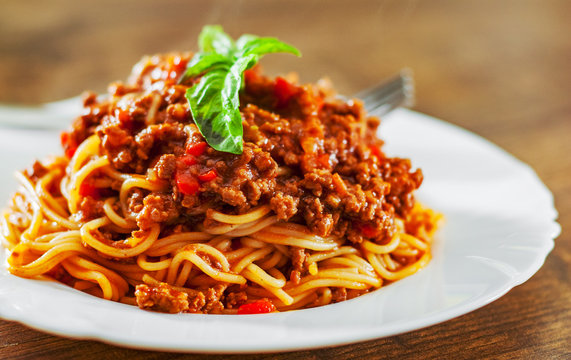


             FOOD CALORIE PREDICTION SYSTEM

Predicted Food : spaghetti_bolognese
Confidence     : 98.96%

USDA Food      : SPAGHETTI BOLOGNESE ITALIAN RECIPE SPAGHETTI WITH BEEF BOLOGNESE SAUCE, SPAGHETTI BOLOGNESE
Estimated Energy: 112.00 KCAL

Prediction Assessment: High confidence

Nutrition Status:
USDA nutrition information found.

Note: The calorie value is an estimate based on the matched USDA nutrition record.
Actual calories can vary depending on portion size, ingredients and preparation.


In [ ]:
# 14J. FINAL FOOD CALORIE PREDICTION RESULT

from IPython.display import display
from IPython.display import Image as DisplayImage


# Display the uploaded food image.


print()
print(
    "Uploaded food image:"
)

display(
    DisplayImage(
        filename=image_path
    )
)


# Get the nutrition information from the result.

usda_food = nutrition_result.get(
    "usda_food"
)

calories = nutrition_result.get(
    "calories"
)

calorie_unit = nutrition_result.get(
    "unit"
)

nutrition_message = nutrition_result.get(
    "message"
)


# Display the complete result.

print()
print("=" * 70)

print(
    "             FOOD CALORIE PREDICTION SYSTEM"
)

print("=" * 70)

print()

print(
    f"Predicted Food : {predicted_food}"
)

print(
    f"Confidence     : {confidence:.2f}%"
)

print()


# Display USDA food match.

if usda_food is not None:

    print(
        f"USDA Food      : {usda_food}"
    )

else:

    print(
        "USDA Food      : No matching food record found"
    )


# Display calorie information.

if calories is not None:

    print(
        f"Estimated Energy: "
        f"{calories:.2f} {calorie_unit}"
    )

else:

    print(
        "Estimated Energy: Not available"
    )


print()


# Give a simple interpretation of the model confidence.

if confidence >= 80:

    print(
        "Prediction Assessment: High confidence"
    )

elif confidence >= 50:

    print(
        "Prediction Assessment: Moderate confidence"
    )

else:

    print(
        "Prediction Assessment: Low confidence"
    )

    print(
        "The model is uncertain about this prediction."
    )


print()

print(
    "Nutrition Status:"
)

print(
    nutrition_message
)

print()

print(
    "Note: The calorie value is an estimate based on "
    "the matched USDA nutrition record."
)

print(
    "Actual calories can vary depending on portion size, "
    "ingredients and preparation."
)

print("=" * 70)